# Эмпирическая валидация модели инфодемий на Hoaxy

Этот ноутбук является приложением к работе **«Моделирование распространения инфодемий через конкурентную перколяцию»**.

Цель ноутбука — проверить на реальном датасете Hoaxy ключевые механизмы исходной модели:

1. наличие модульной структуры сети, интерпретируемой как эхо-камеры;
2. роль межсообщественных мостов как каналов перколяции claim-контента;
3. наличие центральных узлов / инфлюенсеров;
4. доминирование claim-контента в ядре сети;
5. преимущество таргетированного воздействия перед случайным;
6. применимость исходной competitive-percolation динамики `S/F/C` на реальной топологии Hoaxy;
7. наличие эмпирического аналога перколяционного порога `p_c`, фазовой карты `p × r` и эффекта задержки `delay`.

В терминах исходной статьи используется соответствие:

- `S` — пользователь, ещё не вовлечённый в рассматриваемую информационную волну;
- `F` — пользователь / событие, связанное с `claim`-контентом;
- `C` — пользователь / событие, связанное с `fact-check`-контентом.

Важно: в реальных данных `claim` не следует автоматически называть доказанным «фейком» в юридическом смысле. В этом ноутбуке `claim` используется как эмпирический аналог состояния `F` из модели, а `fact` — как аналог состояния `C`.


## 0. Настройки запуска

По умолчанию ноутбук настроен так, чтобы его можно было запустить в Colab или локальном Jupyter за разумное время.  
Для финального пересчёта таблиц перед публикацией можно поставить:

```python
RUN_MODE = "paper"
```

Это увеличит число Монте-Карло запусков и размер реального графа для динамической валидации.


In [ ]:
# ===== Cell 0. Global configuration =====

RUN_MODE = "fast"  # "fast" для проверки; "paper" для финального пересчета перед статьей

CONFIG = {
    "MAX_NODES_STRUCTURAL": 50_000,
    "VALIDATION_NODES": 8_000 if RUN_MODE == "fast" else 15_000,
    "FAKE_SEED_POOL_N": 500,
    "REAL_PC_RUNS": 30 if RUN_MODE == "fast" else 100,
    "REAL_STRATEGY_RUNS": 60 if RUN_MODE == "fast" else 150,
    "REAL_PR_GRID": 7 if RUN_MODE == "fast" else 9,
    "REAL_PR_RUNS": 20 if RUN_MODE == "fast" else 60,
    "REAL_DELAY_RUNS": 60 if RUN_MODE == "fast" else 150,
    "TEMPORAL_RANDOM_REPS": 200 if RUN_MODE == "fast" else 500,
}

CONFIG


{'MAX_NODES_STRUCTURAL': 50000,
 'VALIDATION_NODES': 8000,
 'FAKE_SEED_POOL_N': 500,
 'REAL_PC_RUNS': 30,
 'REAL_STRATEGY_RUNS': 60,
 'REAL_PR_GRID': 7,
 'REAL_PR_RUNS': 20,
 'REAL_DELAY_RUNS': 60,
 'TEMPORAL_RANDOM_REPS': 200}

## 1. Импорт библиотек и общие настройки

В этой ячейке подключаются библиотеки для обработки таблиц, построения графов, поиска сообществ, Монте-Карло симуляций и визуализации.  
Также создаются папки для данных и рисунков, чтобы все графики можно было напрямую использовать в приложении к статье.


In [ ]:
# ===== Cell 1. Setup =====

!pip -q install python-louvain tqdm

import os
import zipfile
import json
import math
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_ROOT = Path("hoaxy_data")
FIG_DIR = Path("validation_figs")
TABLE_DIR = Path("validation_tables")

DATA_ROOT.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
})


def save_current_fig(filename):
    """Сохраняет текущую matplotlib-фигуру в папку validation_figs."""
    path = FIG_DIR / filename
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


print("RUN_MODE:", RUN_MODE)
print("CONFIG:", CONFIG)
print("NetworkX version:", nx.__version__)


RUN_MODE: fast
CONFIG: {'MAX_NODES_STRUCTURAL': 50000, 'VALIDATION_NODES': 8000, 'FAKE_SEED_POOL_N': 500, 'REAL_PC_RUNS': 30, 'REAL_STRATEGY_RUNS': 60, 'REAL_PR_GRID': 7, 'REAL_PR_RUNS': 20, 'REAL_DELAY_RUNS': 60, 'TEMPORAL_RANDOM_REPS': 200}
NetworkX version: 3.6.1


## 2. Загрузка Hoaxy-датасета

Используется архив Hoaxy / PLOS dataset с ретвит-сетью до выборов 2016 года.  
Если архив уже скачан, ячейка не загружает его повторно. После распаковки в папке `hoaxy_data/release_datasets` должен появиться файл `retweet.preelection.all.csv`.


In [ ]:
# ===== Cell 2. Download Hoaxy Zenodo dataset =====

HOAXY_ZIP_URL = "https://zenodo.org/records/1154840/files/PLOS_hoaxy_network_dataset.zip?download=1"
HOAXY_ZIP_PATH = DATA_ROOT / "PLOS_hoaxy_network_dataset.zip"

if not HOAXY_ZIP_PATH.exists():
    print("Downloading Hoaxy dataset...")
    !wget -q -O {HOAXY_ZIP_PATH} "{HOAXY_ZIP_URL}"
else:
    print("Archive already exists:", HOAXY_ZIP_PATH)

with zipfile.ZipFile(HOAXY_ZIP_PATH, "r") as z:
    z.extractall(DATA_ROOT)

print("Downloaded and extracted to:", DATA_ROOT)

for path in sorted(DATA_ROOT.rglob("*")):
    print(path)


Downloaded and extracted to: hoaxy_data
hoaxy_data/PLOS_hoaxy_network_dataset.zip
hoaxy_data/release_datasets
hoaxy_data/release_datasets/README.pdf
hoaxy_data/release_datasets/retweet.postelection.claim.csv
hoaxy_data/release_datasets/retweet.preelection.all.csv


## 3. Чтение таблицы ретвит-событий

Файл `retweet.preelection.all.csv` содержит события распространения claim- и fact-check-контента.  
Дальше каждая строка интерпретируется как одно направленное событие между двумя пользователями.


In [ ]:
# ===== Cell 3. Load retweet events =====

DATA_DIR = Path("hoaxy_data/release_datasets")
RETWEET_PATH = DATA_DIR / "retweet.preelection.all.csv"

if not RETWEET_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {RETWEET_PATH}. Проверь, что предыдущая ячейка скачала и распаковала архив."
    )

pre = pd.read_csv(RETWEET_PATH)

print("Raw table shape:", pre.shape)
print("Columns:", list(pre.columns))

display(pre.head())

required_cols = {"from_user_id", "to_user_id", "tweet_id", "tweet_created_at", "site_type"}
missing = required_cols - set(pre.columns)
if missing:
    raise ValueError(f"В таблице не хватает колонок: {missing}")

print("site_type distribution:")
display(pre["site_type"].value_counts(dropna=False).head(20))


Raw table shape: (2132235, 5)
Columns: ['from_user_id', 'to_user_id', 'tweet_id', 'tweet_created_at', 'site_type']


,from_user_id,to_user_id,tweet_id,tweet_created_at,site_type
0,19470460,715467914313404416,732086742744883202,2016-05-16 05:54:15,claim
1,41635723,2696919212,732086881530216449,2016-05-16 05:54:48,claim
2,109065990,19788053,732086952997060609,2016-05-16 05:55:05,claim
3,177883234,58684386,732087986876125186,2016-05-16 05:59:12,claim
4,73572581,2893898514,732087999412850688,2016-05-16 05:59:15,claim


site_type distribution:


,count
site_type,
claim,1746867
fact_checking,385368


## 4. Сопоставление Hoaxy-разметки с состояниями модели `F` и `C`

В исходной competitive-percolation модели есть две конкурирующие информационные волны:

- `F` — распространение claim / misinformation-like контента;
- `C` — распространение fact-check контента.

Эта ячейка переводит поле `site_type` в модельное состояние `state`.


In [ ]:
# ===== Cell 4. Map Hoaxy site_type to model states =====

def map_state(site_type):
    s = str(site_type).lower()

    if "claim" in s:
        return "F"
    if "fact" in s:
        return "C"
    return "unknown"


pre["state"] = pre["site_type"].apply(map_state)

state_counts = pre["state"].value_counts()
display(state_counts.rename_axis("state").reset_index(name="events"))

if "unknown" in state_counts.index:
    print("Warning: unknown rows found:", int(state_counts.loc["unknown"]))


,state,events
0,F,1746867
1,C,385368


## 5. Нормализация событий

Создаём компактную таблицу `events`, которая будет использоваться во всех последующих блоках.

Колонки:

- `source` — пользователь-источник события;
- `target` — пользователь-получатель / связанный пользователь;
- `timestamp` — время события;
- `state` — `F` или `C`.

Самопетли удаляются, потому что они не несут информации о распространении по сети.


In [ ]:
# ===== Cell 5. Create normalized event table =====

events = pd.DataFrame({
    "source": pre["from_user_id"].astype(str),
    "target": pre["to_user_id"].astype(str),
    "tweet_id": pre["tweet_id"].astype(str),
    "timestamp": pd.to_datetime(pre["tweet_created_at"], errors="coerce"),
    "state": pre["state"],
})

events = events.dropna(subset=["timestamp"])
events = events[events["source"] != events["target"]]
events = events[events["state"].isin(["F", "C"])]

print("Normalized events shape:", events.shape)
print("Time range:", events["timestamp"].min(), "—", events["timestamp"].max())

display(events.head())
display(events["state"].value_counts().rename_axis("state").reset_index(name="events"))


Normalized events shape: (2132235, 5)
Time range: 2016-05-16 05:54:15 — 2016-11-07 23:59:54


,source,target,tweet_id,timestamp,state
0,19470460,715467914313404416,732086742744883202,2016-05-16 05:54:15,F
1,41635723,2696919212,732086881530216449,2016-05-16 05:54:48,F
2,109065990,19788053,732086952997060609,2016-05-16 05:55:05,F
3,177883234,58684386,732087986876125186,2016-05-16 05:59:12,F
4,73572581,2893898514,732087999412850688,2016-05-16 05:59:15,F


,state,events
0,F,1746867
1,C,385368


## 6. Наблюдаемая накопительная динамика `F` и `C`

Это не симуляция, а прямое описание временной динамики в датасете.  
На каждом временном шаге считается доля пользователей, которые хотя бы раз появились в claim-событиях (`F_obs`) или fact-check-событиях (`C_obs`).

Эта кривая нужна как первичная эмпирическая картина: насколько быстрее и шире распространяется claim-контент относительно fact-check-контента.


,t,F_obs,C_obs,F_users_cum,C_users_cum,active_users
699,699,0.623303,0.432587,216020,149923,346573
700,700,0.623303,0.432587,216020,149923,346573
701,701,0.624596,0.433239,216468,150149,346573
702,702,0.626913,0.434217,217271,150488,346573
703,703,0.626936,0.434240,217279,150496,346573


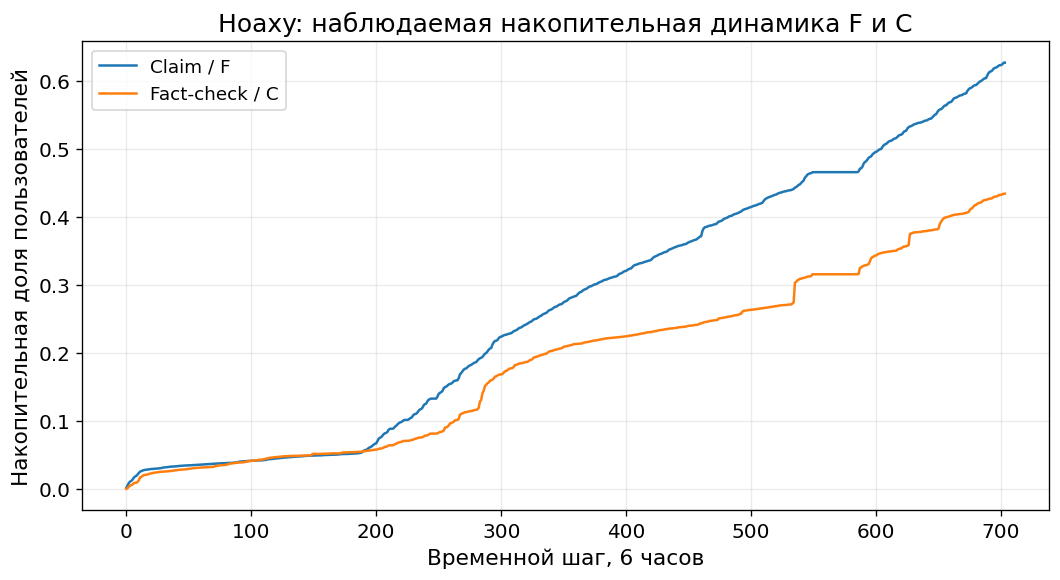

In [ ]:
# ===== Cell 6. Observed cumulative dynamics =====

def observed_history(events_df, freq="6H"):
    df = events_df.copy().sort_values("timestamp")

    start = df["timestamp"].min()
    dt = pd.Timedelta(freq).total_seconds()

    df["t"] = ((df["timestamp"] - start).dt.total_seconds() // dt).astype(int)

    nodes = set(df["source"]) | set(df["target"])
    N = len(nodes)

    F_set = set()
    C_set = set()

    rows = []

    for t in range(df["t"].max() + 1):
        part = df[df["t"] == t]

        F_set.update(part.loc[part["state"] == "F", "target"])
        C_set.update(part.loc[part["state"] == "C", "target"])

        rows.append({
            "t": t,
            "F_obs": len(F_set) / N,
            "C_obs": len(C_set) / N,
            "F_users_cum": len(F_set),
            "C_users_cum": len(C_set),
            "active_users": N,
        })

    return pd.DataFrame(rows)


obs = observed_history(events, freq="6H")
display(obs.tail())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(obs["t"], obs["F_obs"], label="Claim / F")
ax.plot(obs["t"], obs["C_obs"], label="Fact-check / C")
ax.set_xlabel("Временной шаг, 6 часов")
ax.set_ylabel("Накопительная доля пользователей")
ax.set_title("Hoaxy: наблюдаемая накопительная динамика F и C")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "hoaxy_observed_cumulative_dynamics.png", bbox_inches="tight")
plt.show()


## 7. Построение агрегированного графа Hoaxy

Из событий строится взвешенный ориентированный граф `G`.

Ребро `source → target` получает атрибуты:

- `n_events` — общее число событий между парой пользователей;
- `n_F` — число claim-событий;
- `n_C` — число fact-check-событий;
- `edge_state` — доминирующий тип ребра;
- `weight` — нормированный логарифмический вес ребра.

Логарифмирование нужно, чтобы сверхактивные пары пользователей не разрушали масштаб весов.


In [ ]:
# ===== Cell 7. Build aggregated directed Hoaxy graph =====

edge_table = (
    events
    .groupby(["source", "target"], as_index=False)
    .agg(
        n_events=("state", "size"),
        n_F=("state", lambda s: int((s == "F").sum())),
        n_C=("state", lambda s: int((s == "C").sum())),
        first_time=("timestamp", "min"),
        last_time=("timestamp", "max"),
    )
)


def edge_state(row):
    if row["n_F"] > row["n_C"]:
        return "F"
    if row["n_C"] > row["n_F"]:
        return "C"
    if row["n_F"] > 0 and row["n_C"] > 0:
        return "mixed"
    return "unknown"


edge_table["edge_state"] = edge_table.apply(edge_state, axis=1)

# Вес ребра: логарифмируем число событий и нормируем по 95-му перцентилю.
x = np.log1p(edge_table["n_events"].values.astype(float))
q95 = np.quantile(x, 0.95)

if q95 > 0:
    edge_table["weight"] = np.clip(x / q95, 0.05, 1.0)
else:
    edge_table["weight"] = 1.0

G = nx.DiGraph()

for _, row in tqdm(edge_table.iterrows(), total=len(edge_table), desc="Building directed graph"):
    G.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        n_events=int(row["n_events"]),
        n_F=int(row["n_F"]),
        n_C=int(row["n_C"]),
        edge_state=row["edge_state"],
        first_time=row["first_time"],
        last_time=row["last_time"],
    )

print("Directed graph G")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

display(edge_table.head())
display(edge_table["edge_state"].value_counts().rename_axis("edge_state").reset_index(name="edges"))

edge_table.to_csv(TABLE_DIR / "hoaxy_edge_table.csv", index=False)


Building directed graph:   0%|          | 0/1091552 [00:00<?, ?it/s]

Directed graph G
Nodes: 346573
Edges: 1091552


,source,target,n_events,n_F,n_C,first_time,last_time,edge_state,weight
0,100005598,135624812,1,0,1,2016-07-15 02:07:44,2016-07-15 02:07:44,C,0.386853
1,100005598,355028519,1,0,1,2016-07-15 04:27:18,2016-07-15 04:27:18,C,0.386853
2,100005598,54182891,1,0,1,2016-07-15 02:05:40,2016-07-15 02:05:40,C,0.386853
3,100005598,86123044,1,0,1,2016-07-15 02:14:05,2016-07-15 02:14:05,C,0.386853
4,100009414,53452045,1,1,0,2016-05-18 03:45:26,2016-05-18 03:45:26,F,0.386853


,edge_state,edges
0,F,814333
1,C,275415
2,mixed,1804


## 8. Рабочий неориентированный граф и эхо-камеры

Для анализа модульности и перколяции используется неориентированная версия графа `UG`.  
Дальше выделяется крупнейшая связная компонента и, при необходимости, высокосвязное ядро из `MAX_NODES_STRUCTURAL` узлов.

Затем алгоритм Louvain выделяет сообщества. Эти сообщества являются эмпирическим аналогом эхо-камер из исходной синтетической модели.


In [ ]:
# ===== Cell 8. Communities / echo chambers =====

UG = nx.Graph(G)

print("Full undirected graph:")
print("Nodes:", UG.number_of_nodes())
print("Edges:", UG.number_of_edges())

largest_cc = max(nx.connected_components(UG), key=len)
UG_lcc = UG.subgraph(largest_cc).copy()

print("\nLargest connected component:")
print("Nodes:", UG_lcc.number_of_nodes())
print("Edges:", UG_lcc.number_of_edges())

MAX_NODES = CONFIG["MAX_NODES_STRUCTURAL"]

if UG_lcc.number_of_nodes() > MAX_NODES:
    weighted_degree = dict(UG_lcc.degree(weight="weight"))
    top_nodes = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:MAX_NODES]
    UG_work = UG_lcc.subgraph(top_nodes).copy()
else:
    UG_work = UG_lcc.copy()

print("\nWorking graph:")
print("Nodes:", UG_work.number_of_nodes())
print("Edges:", UG_work.number_of_edges())

# Louvain communities. Сначала пробуем встроенную реализацию NetworkX,
# если она недоступна — fallback к пакету python-louvain.
try:
    communities = nx.community.louvain_communities(
        UG_work,
        weight="weight",
        seed=SEED,
        resolution=1.0,
    )
    partition = {}
    for community_id, nodes in enumerate(communities):
        for node in nodes:
            partition[node] = community_id
except Exception as e:
    print("NetworkX Louvain failed, fallback to python-louvain:", repr(e))
    import community as community_louvain
    partition = community_louvain.best_partition(
        UG_work,
        weight="weight",
        random_state=SEED,
        resolution=1.0,
    )
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)
    communities = [set(nodes) for nodes in communities_dict.values()]

nx.set_node_attributes(UG_work, partition, "community")

print("\nCommunities:", len(communities))

community_sizes = (
    pd.Series(partition)
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("community")
    .reset_index(name="size")
)

display(community_sizes.head(20))
community_sizes.to_csv(TABLE_DIR / "hoaxy_louvain_community_sizes.csv", index=False)


Full undirected graph:
Nodes: 346573
Edges: 1088260

Largest connected component:
Nodes: 330968
Edges: 1077384

Working graph:
Nodes: 50000
Edges: 654035

Communities: 285


,community,size
0,225,19641
1,177,15252
2,174,7865
3,136,6795
4,270,68
5,20,55
6,157,21
7,194,8
8,68,6
9,93,3


## 9. Рабочий ориентированный граф с разметкой сообществ

На этом этапе создаётся `G_work` — ориентированный подграф на тех же узлах, что и `UG_work`.  
Каждое ребро размечается как:

- `intra` — оба конца ребра находятся в одном Louvain-сообществе;
- `bridge` — ребро соединяет разные сообщества.

Эта разметка нужна для проверки гипотезы о мостах как каналах межгрупповой перколяции.


In [ ]:
# ===== Cell 9. Create working directed graph with communities =====

analysis_nodes = set(UG_work.nodes())
G_work = G.subgraph(analysis_nodes).copy()

for n in G_work.nodes():
    G_work.nodes[n]["community"] = UG_work.nodes[n]["community"]

for u, v in G_work.edges():
    cu = G_work.nodes[u]["community"]
    cv = G_work.nodes[v]["community"]
    G_work[u][v]["edge_type"] = "intra" if cu == cv else "bridge"

print("Working directed graph:")
print("Nodes:", G_work.number_of_nodes())
print("Edges:", G_work.number_of_edges())

print("\nWorking undirected graph:")
print("Nodes:", UG_work.number_of_nodes())
print("Edges:", UG_work.number_of_edges())


Working directed graph:
Nodes: 50000
Edges: 657013

Working undirected graph:
Nodes: 50000
Edges: 654035


## 10. Доля мостовых и внутригрупповых рёбер

Эта ячейка отвечает на первый структурный вопрос: насколько реальная Hoaxy-сеть действительно является модульной и сколько в ней межсообщественных каналов.

Если мостовые рёбра существуют и занимают заметную долю сети, то исходная перколяционная идея «локальная вспышка → переход через мосты → глобальная инфодемия» имеет эмпирическую основу.


In [ ]:
# ===== Cell 10. Bridges in the working Hoaxy graph =====

bridge = 0
intra = 0

for u, v in UG_work.edges():
    cu = UG_work.nodes[u]["community"]
    cv = UG_work.nodes[v]["community"]

    if cu == cv:
        intra += 1
    else:
        bridge += 1

bridge_summary = pd.DataFrame([
    {
        "intra_edges": intra,
        "bridge_edges": bridge,
        "bridge_share": bridge / max(1, bridge + intra),
    }
])

display(bridge_summary)
bridge_summary.to_csv(TABLE_DIR / "hoaxy_bridge_summary.csv", index=False)


,intra_edges,bridge_edges,bridge_share
0,452416,201619,0.308269


## 11. Центральные узлы / эмпирические инфлюенсеры

В исходной модели инфлюенсеры задавались искусственно как узлы с высокой степенью.  
На реальном Hoaxy-графе центральные узлы оцениваются через PageRank и degree. Эти узлы используются далее как эмпирические кандидаты для таргетированного fact-check вмешательства.


In [ ]:
# ===== Cell 11. Influencers / central nodes =====

try:
    pagerank = nx.pagerank(G_work, weight="weight", max_iter=300)
except nx.PowerIterationFailedConvergence:
    print("PageRank did not converge with 300 iterations; retrying with 1000...")
    pagerank = nx.pagerank(G_work, weight="weight", max_iter=1000)

centrality_df = pd.DataFrame({
    "node": list(pagerank.keys()),
    "pagerank": list(pagerank.values()),
})

# Добавляем degree на неориентированном рабочем графе.
degree_unweighted = dict(UG_work.degree())
degree_weighted = dict(UG_work.degree(weight="weight"))
centrality_df["degree"] = centrality_df["node"].map(degree_unweighted)
centrality_df["weighted_degree"] = centrality_df["node"].map(degree_weighted)
centrality_df["community"] = centrality_df["node"].map(lambda n: UG_work.nodes[n]["community"])

centrality_df = centrality_df.sort_values("pagerank", ascending=False).reset_index(drop=True)

display(centrality_df.head(20))
centrality_df.to_csv(TABLE_DIR / "hoaxy_centrality_topology.csv", index=False)

# Не выводим интерпретацию конкретных user_id; в статье лучше описывать агрегированные свойства.
top_influencers = centrality_df.head(20)["node"].tolist()
print("Number of top influencers stored:", len(top_influencers))


,node,pagerank,degree,weighted_degree,community
0,3376927462,0.001121,345,165.767685,225
1,368544047,0.000911,2553,1165.496167,177
2,134240162,0.000525,1369,613.351240,177
3,4855687055,0.000413,5397,2787.838477,177
4,2315583427,0.000398,2874,1354.281681,177
5,4521330855,0.000341,110,59.023507,136
6,720008230412410885,0.000332,3103,1615.606875,177
7,3172991259,0.000324,70,27.532285,177
8,4839403219,0.000296,1554,751.898929,177
9,97989357,0.000295,202,94.371821,225


Number of top influencers stored: 20


## 12. Claim/fact-check на мостовых и внутригрупповых рёбрах

Здесь проверяется главный топологический механизм модели: действительно ли межсообщественные мосты несут непропорционально большую долю claim-контента.

Если на `bridge`-рёбрах доля `F` выше, чем на `intra`-рёбрах, это поддерживает тезис, что мосты являются критическими каналами межгрупповой перколяции.


,edge_type,edges,total_events,F_events,C_events,F_share,C_share
0,bridge,201990,464269,436986,27283,0.941234,0.058766
1,intra,455023,1085488,941102,144386,0.866985,0.133015


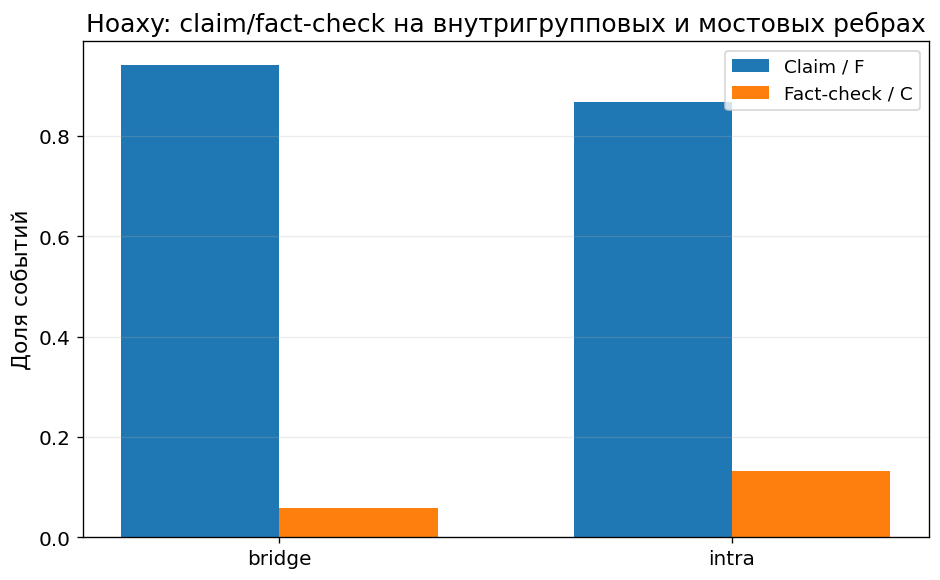

In [ ]:
# ===== Cell 12. Event-weighted claim/fact-check across intra / bridge edges =====

rows = []

for u, v, d in G_work.edges(data=True):
    rows.append({
        "edge_type": d.get("edge_type", "unknown"),
        "n_events": d.get("n_events", 0),
        "n_F": d.get("n_F", 0),
        "n_C": d.get("n_C", 0),
        "edge_state": d.get("edge_state", "unknown"),
    })

fc_edge_df = pd.DataFrame(rows)

summary_fc = (
    fc_edge_df
    .groupby("edge_type")
    .agg(
        edges=("edge_type", "size"),
        total_events=("n_events", "sum"),
        F_events=("n_F", "sum"),
        C_events=("n_C", "sum"),
    )
    .reset_index()
)

summary_fc["F_share"] = summary_fc["F_events"] / summary_fc["total_events"]
summary_fc["C_share"] = summary_fc["C_events"] / summary_fc["total_events"]

display(summary_fc)
summary_fc.to_csv(TABLE_DIR / "hoaxy_bridge_intra_claim_fact_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(summary_fc))
width = 0.35

ax.bar(x - width / 2, summary_fc["F_share"], width, label="Claim / F")
ax.bar(x + width / 2, summary_fc["C_share"], width, label="Fact-check / C")

ax.set_xticks(x)
ax.set_xticklabels(summary_fc["edge_type"])
ax.set_ylabel("Доля событий")
ax.set_title("Hoaxy: claim/fact-check на внутригрупповых и мостовых ребрах")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "hoaxy_bridge_intra_claim_fact_share.png", bbox_inches="tight")
plt.show()


## 13. Статистическая проверка: claim-доминирование на мостах

Предыдущий график даёт визуальную проверку. Здесь добавляется количественный тест через event-weighted odds ratio.

Интерпретация:

- `OR > 1` означает, что отношение `claim/fact-check` на мостовых рёбрах выше, чем на внутригрупповых;
- доверительный интервал и приближённое `p-value` показывают, насколько устойчиво это различие на уровне событий.


In [ ]:
# ===== Cell 13. Statistical test: bridge edges vs intra edges =====

summary_fc2 = (
    fc_edge_df
    .groupby("edge_type")
    .agg(
        edges=("edge_type", "size"),
        total_events=("n_events", "sum"),
        F_events=("n_F", "sum"),
        C_events=("n_C", "sum"),
    )
    .reset_index()
)

summary_fc2["F_share"] = summary_fc2["F_events"] / summary_fc2["total_events"]
summary_fc2["C_share"] = summary_fc2["C_events"] / summary_fc2["total_events"]

display(summary_fc2)

piv = summary_fc2.set_index("edge_type")
required = {"bridge", "intra"}

if required.issubset(set(piv.index)):
    a = float(piv.loc["bridge", "F_events"])
    b = float(piv.loc["bridge", "C_events"])
    c = float(piv.loc["intra", "F_events"])
    d = float(piv.loc["intra", "C_events"])

    # Коррекция Халдейна-Энскомба на случай нулевых ячеек.
    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_ratio = (a / b) / (c / d)
    log_or = math.log(odds_ratio)
    se = math.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    ci_low = math.exp(log_or - 1.96 * se)
    ci_high = math.exp(log_or + 1.96 * se)
    z = log_or / se
    p_value = math.erfc(abs(z) / math.sqrt(2))

    bridge_gap = float(piv.loc["bridge", "F_share"] - piv.loc["intra", "F_share"])

    test_summary = pd.DataFrame([{
        "bridge_F_share": float(piv.loc["bridge", "F_share"]),
        "intra_F_share": float(piv.loc["intra", "F_share"]),
        "F_share_gap_bridge_minus_intra": bridge_gap,
        "claim_odds_ratio_bridge_vs_intra": odds_ratio,
        "OR_95CI_low": ci_low,
        "OR_95CI_high": ci_high,
        "z_score": z,
        "p_value_approx": p_value,
    }])

    display(test_summary)
    test_summary.to_csv(TABLE_DIR / "hoaxy_bridge_vs_intra_odds_ratio.csv", index=False)
else:
    print("Не найдены оба типа ребер: bridge и intra. Проверь edge_type в G_work.")


,edge_type,edges,total_events,F_events,C_events,F_share,C_share
0,bridge,201990,464269,436986,27283,0.941234,0.058766
1,intra,455023,1085488,941102,144386,0.866985,0.133015


,bridge_F_share,intra_F_share,F_share_gap_bridge_minus_intra,claim_odds_ratio_bridge_vs_intra,OR_95CI_low,OR_95CI_high,z_score,p_value_approx
0,0.941234,0.866985,0.074249,2.457332,2.424558,2.490549,131.241879,0.0


## 14. Пересечение пользователей `F` и `C`

Эта проверка показывает, являются ли claim- и fact-check-аудитории полностью раздельными.  
Наличие пересечения означает, что две информационные волны потенциально конкурируют за одних и тех же пользователей.

Ограничение: пересечение не доказывает факт переубеждения `F → C`; оно только показывает совместное присутствие пользователя в обоих типах событий.


In [ ]:
# ===== Cell 14. User overlap between F and C =====

F_users = set(events.loc[events["state"] == "F", "target"])
C_users = set(events.loc[events["state"] == "C", "target"])

all_active_users = F_users | C_users
overlap_users = F_users & C_users

overlap_summary = pd.DataFrame([
    {
        "F_users": len(F_users),
        "C_users": len(C_users),
        "overlap_users": len(overlap_users),
        "active_users": len(all_active_users),
        "F_share_among_active": len(F_users) / len(all_active_users),
        "C_share_among_active": len(C_users) / len(all_active_users),
        "overlap_share_among_active": len(overlap_users) / len(all_active_users),
    }
])

display(overlap_summary)
overlap_summary.to_csv(TABLE_DIR / "hoaxy_F_C_user_overlap.csv", index=False)


,F_users,C_users,overlap_users,active_users,F_share_among_active,C_share_among_active,overlap_share_among_active
0,217279,150496,38536,329239,0.659943,0.457103,0.117046


## 15. K-core анализ: где находится claim- и fact-check-контент

K-core decomposition показывает, как контент распределён от периферии сети к её плотному ядру.

Если в глубоких k-core слоях fact-check почти исчезает, это означает, что корректирующая информация плохо представлена в структурно важных областях сети. Для исходной модели это поддерживает идею необходимости таргетированного запуска `C` через центральные узлы.


,k_core,edges,total_events,F_events,C_events,F_share,C_share
30,31,8336,21142,20585,557,0.973654,0.026346
31,32,8796,20167,19580,587,0.970893,0.029107
32,33,7502,20308,19769,539,0.973459,0.026541
33,34,6293,13178,12786,392,0.970253,0.029747
34,35,7547,19825,19154,671,0.966154,0.033846
35,36,6757,14827,14382,445,0.969987,0.030013
36,37,6144,13779,13356,423,0.969301,0.030699
37,38,7299,17099,16608,491,0.971285,0.028715
38,39,6938,17511,16916,595,0.966021,0.033979
39,40,6644,16891,16520,371,0.978036,0.021964


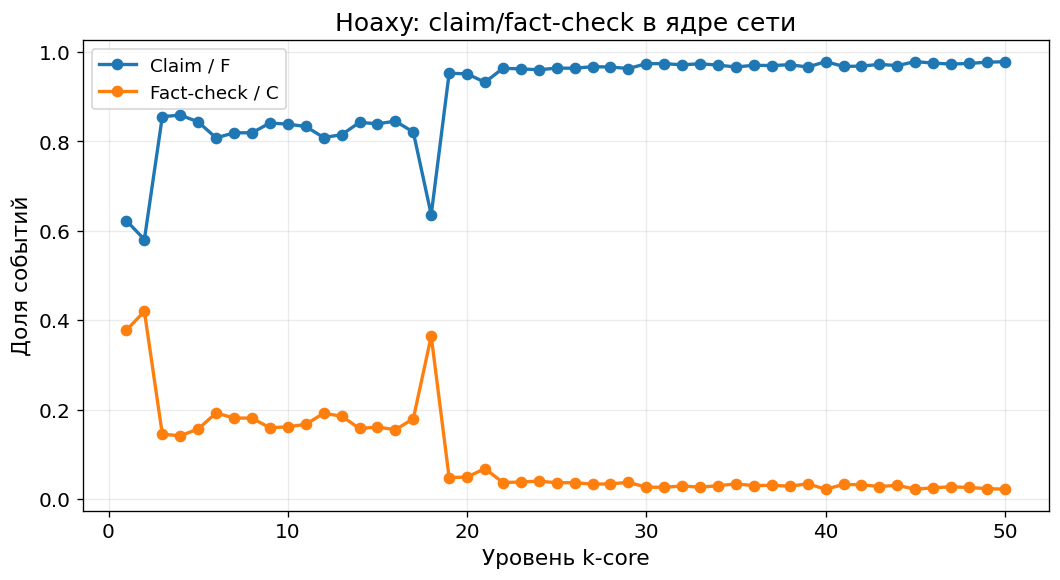

In [ ]:
# ===== Cell 15. K-core analysis =====

core_number = nx.core_number(UG_work)

rows = []

for u, v, d in G_work.edges(data=True):
    if u not in core_number or v not in core_number:
        continue

    k = min(core_number[u], core_number[v])

    rows.append({
        "k_core": k,
        "n_events": d.get("n_events", 0),
        "n_F": d.get("n_F", 0),
        "n_C": d.get("n_C", 0),
    })

core_df = pd.DataFrame(rows)

core_summary = (
    core_df
    .groupby("k_core")
    .agg(
        edges=("k_core", "size"),
        total_events=("n_events", "sum"),
        F_events=("n_F", "sum"),
        C_events=("n_C", "sum"),
    )
    .reset_index()
)

core_summary["F_share"] = core_summary["F_events"] / core_summary["total_events"]
core_summary["C_share"] = core_summary["C_events"] / core_summary["total_events"]

display(core_summary.tail(20))
core_summary.to_csv(TABLE_DIR / "hoaxy_k_core_claim_fact_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(core_summary["k_core"], core_summary["F_share"], marker="o", linewidth=2, label="Claim / F")
ax.plot(core_summary["k_core"], core_summary["C_share"], marker="o", linewidth=2, label="Fact-check / C")
ax.set_xlabel("Уровень k-core")
ax.set_ylabel("Доля событий")
ax.set_title("Hoaxy: claim/fact-check в ядре сети")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "hoaxy_k_core_claim_fact.png", bbox_inches="tight")
plt.show()


## 16. Структурная интервенция: targeted vs random removal

Это перколяционный стресс-тест реального графа.  
Мы удаляем долю узлов и смотрим, как меняется размер крупнейшей компоненты.

Сравниваются стратегии удаления:

- `random` — случайные узлы;
- `pagerank` — узлы с максимальным PageRank;
- `degree` — узлы с максимальной weighted degree;
- `core` — узлы с максимальным k-core.

Эта ячейка не моделирует fact-check напрямую. Она проверяет структурный механизм: центральные узлы непропорционально важны для глобальной связности сети.


Targeted vs random:   0%|          | 0/11 [00:00<?, ?it/s]

,fraction_removed,strategy,largest_component_share
0,0.00,none,0.994420
1,0.01,pagerank,0.900061
2,0.01,degree,0.900242
3,0.01,core,0.986343
4,0.01,random,0.994364


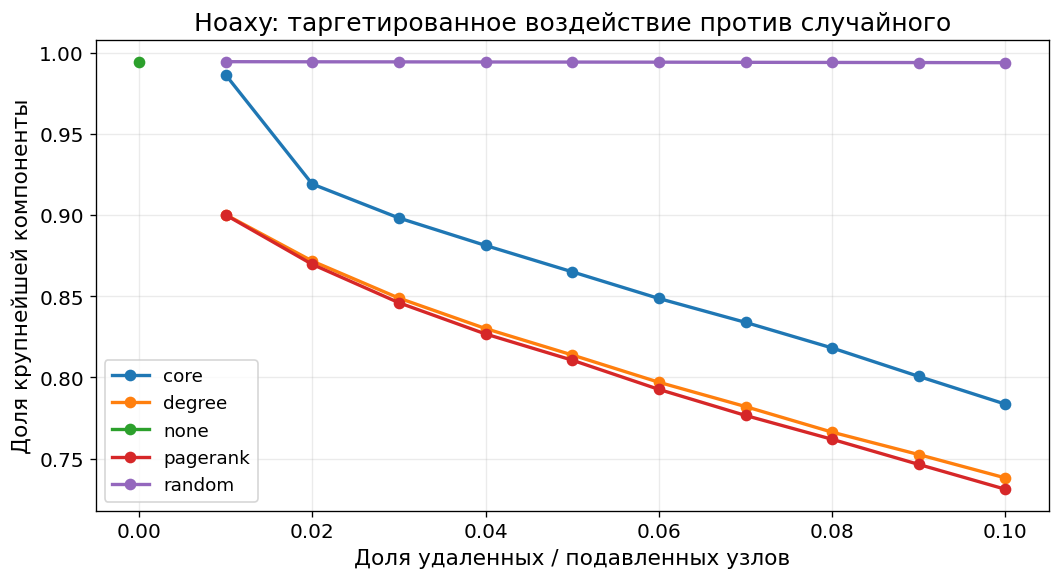

In [ ]:
# ===== Cell 16. Targeted vs random structural intervention =====


def largest_component_share(H):
    if H.number_of_nodes() == 0:
        return 0.0

    components = list(nx.connected_components(nx.Graph(H)))

    if not components:
        return 0.0

    largest = max(components, key=len)
    return len(largest) / H.number_of_nodes()


# Предварительно считаем рейтинги на исходном UG_work, чтобы сравнение было быстрым и воспроизводимым.
try:
    pr_for_removal = nx.pagerank(UG_work, weight="weight", max_iter=500)
except nx.PowerIterationFailedConvergence:
    pr_for_removal = nx.pagerank(UG_work, weight="weight", max_iter=1000)

deg_for_removal = dict(UG_work.degree(weight="weight"))
core_for_removal = core_number

rankings_for_removal = {
    "pagerank": sorted(pr_for_removal, key=pr_for_removal.get, reverse=True),
    "degree": sorted(deg_for_removal, key=deg_for_removal.get, reverse=True),
    "core": sorted(core_for_removal, key=core_for_removal.get, reverse=True),
}


def remove_ranked_nodes(H, ranking, fraction=0.01):
    H2 = H.copy()
    n_remove = max(1, int(fraction * H2.number_of_nodes()))
    nodes_remove = list(ranking[:n_remove])
    H2.remove_nodes_from(nodes_remove)
    return H2


def remove_random_nodes(H, fraction=0.01, seed=42):
    rng = np.random.default_rng(seed)
    H2 = H.copy()
    n_remove = max(1, int(fraction * H2.number_of_nodes()))
    nodes_remove = rng.choice(list(H2.nodes()), size=n_remove, replace=False).tolist()
    H2.remove_nodes_from(nodes_remove)
    return H2


fractions = np.linspace(0.0, 0.10, 11)
rows = []

for frac in tqdm(fractions, desc="Targeted vs random"):
    if frac == 0:
        rows.append({
            "fraction_removed": frac,
            "strategy": "none",
            "largest_component_share": largest_component_share(UG_work),
        })
        continue

    for metric, ranking in rankings_for_removal.items():
        H_removed = remove_ranked_nodes(UG_work, ranking=ranking, fraction=frac)
        rows.append({
            "fraction_removed": frac,
            "strategy": metric,
            "largest_component_share": largest_component_share(H_removed),
        })

    random_values = []
    for i in range(30):
        H_random = remove_random_nodes(UG_work, fraction=frac, seed=SEED + i)
        random_values.append(largest_component_share(H_random))

    rows.append({
        "fraction_removed": frac,
        "strategy": "random",
        "largest_component_share": float(np.mean(random_values)),
    })

intervention_df = pd.DataFrame(rows)
display(intervention_df.head())
intervention_df.to_csv(TABLE_DIR / "hoaxy_targeted_vs_random_removal.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for strategy, part in intervention_df.groupby("strategy"):
    ax.plot(part["fraction_removed"], part["largest_component_share"], marker="o", linewidth=2, label=strategy)

ax.set_xlabel("Доля удаленных / подавленных узлов")
ax.set_ylabel("Доля крупнейшей компоненты")
ax.set_title("Hoaxy: таргетированное воздействие против случайного")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "hoaxy_targeted_vs_random_removal.png", bbox_inches="tight")
plt.show()


## 17. Каскадная валидация по `tweet_id`

Этот блок проверяет уже не только статическую структуру сети, но и реальные claim-каскады.

Идея: если каскад в ранних событиях задевает инфлюенсера или мостовой узел, то он должен в среднем иметь больший охват и чаще выходить за пределы одного сообщества.

Проверяются признаки:

- раннее попадание в top-1% PageRank;
- раннее попадание в мостовой узел;
- корреляции ранней центральности с размером каскада.


F events touching the working graph: 1733199
tweet_id groups with >= 2 F events: 0
tweet_id не дает достаточно многособытийных каскадов; используем temporal episode fallback.


,center_endpoint,other_endpoint,eligible_episodes,mean_events_in_eligible,mean_unique_other_in_eligible
0,source,target,66320,25.210962,20.480835
1,target,source,196204,3.424222,2.461657


Cascade mode: target-centered 12h episodes
Number of F cascades/episodes after filtering: 269987
Cascade mode used: target-centered 12h episodes


,cascade_id,n_events,unique_sources,unique_targets,first_time,last_time,touches_bridge_node,max_pagerank_anywhere,max_degree_anywhere,max_core_anywhere,...,duration_hours,cross_community,log_unique_users,log_unique_targets,cascade_mode,early_max_pagerank,early_max_degree,early_max_core,early_bridge_touch,early_top_1pct_pagerank
0,target:100003814|bin:2016-08-29 12:00:00,2,1,1,2016-08-29 15:03:11,2016-08-29 15:03:15,True,0.000013,23.0,7.0,...,0.001111,False,1.098612,0.693147,target-centered 12h episodes,0.000013,23.0,7.0,True,False
3,target:1000055215|bin:2016-07-29 12:00:00,2,2,1,2016-07-29 18:26:07,2016-07-29 19:10:14,True,0.000014,31653.0,50.0,...,0.735278,False,1.386294,0.693147,target-centered 12h episodes,0.000014,31653.0,50.0,True,False
19,target:1000181929|bin:2016-07-18 12:00:00,2,1,1,2016-07-18 23:40:53,2016-07-18 23:41:17,True,0.000021,31653.0,50.0,...,0.006667,False,1.098612,0.693147,target-centered 12h episodes,0.000021,31653.0,50.0,True,False
20,target:1000181929|bin:2016-07-27 00:00:00,4,2,1,2016-07-27 08:47:29,2016-07-27 08:54:10,True,0.000021,31653.0,50.0,...,0.111389,True,1.386294,0.693147,target-centered 12h episodes,0.000021,31653.0,50.0,True,False
29,target:1000181929|bin:2016-08-12 12:00:00,2,1,1,2016-08-12 16:03:33,2016-08-12 16:26:35,True,0.000021,31653.0,50.0,...,0.383889,False,1.098612,0.693147,target-centered 12h episodes,0.000021,31653.0,50.0,True,False


Early top-1% PageRank effect:


,early_top_1pct_pagerank,cascades,mean_events,median_events,mean_unique_users,median_unique_users,mean_unique_targets,mean_communities,cross_community_prob,mean_duration_hours
0,False,220637,3.248422,2.0,2.957636,3.0,1.0,1.439160,0.420428,2.499690
1,True,49350,3.187254,2.0,3.529747,3.0,1.0,1.642188,0.601196,3.151414


Early bridge-touch effect:


,early_bridge_touch,cascades,mean_events,median_events,mean_unique_users,median_unique_users,mean_unique_targets,mean_communities,cross_community_prob,mean_duration_hours
0,False,495,2.404040,2.0,2.610101,2.0,1.0,1.020202,0.020202,0.658729
1,True,269492,3.238771,2.0,3.063041,3.0,1.0,1.477109,0.454266,2.622416


Spearman correlations between early topology and cascade/episode size:


,unique_users,unique_targets,n_communities,early_max_pagerank,early_max_degree,early_max_core,early_bridge_touch
unique_users,1.000000,NaN,0.347750,0.345263,0.083299,0.115625,0.023966
unique_targets,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_communities,0.347750,NaN,1.000000,0.364661,0.117229,0.130176,0.037009
early_max_pagerank,0.345263,NaN,0.364661,1.000000,-0.257301,0.005430,0.036052
early_max_degree,0.083299,NaN,0.117229,-0.257301,1.000000,0.470791,0.074887
early_max_core,0.115625,NaN,0.130176,0.005430,0.470791,1.000000,0.157857
early_bridge_touch,0.023966,NaN,0.037009,0.036052,0.074887,0.157857,1.000000


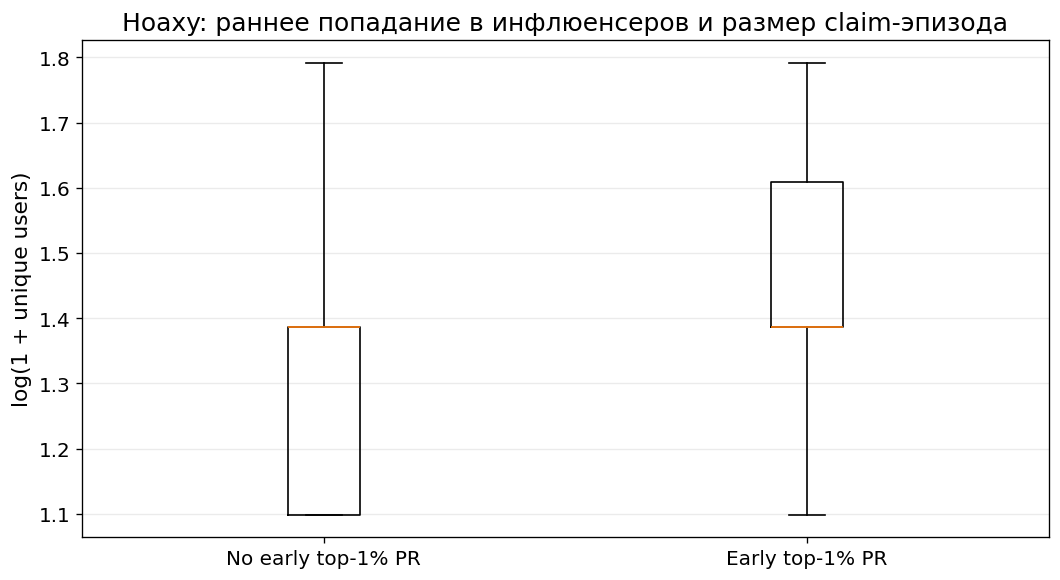

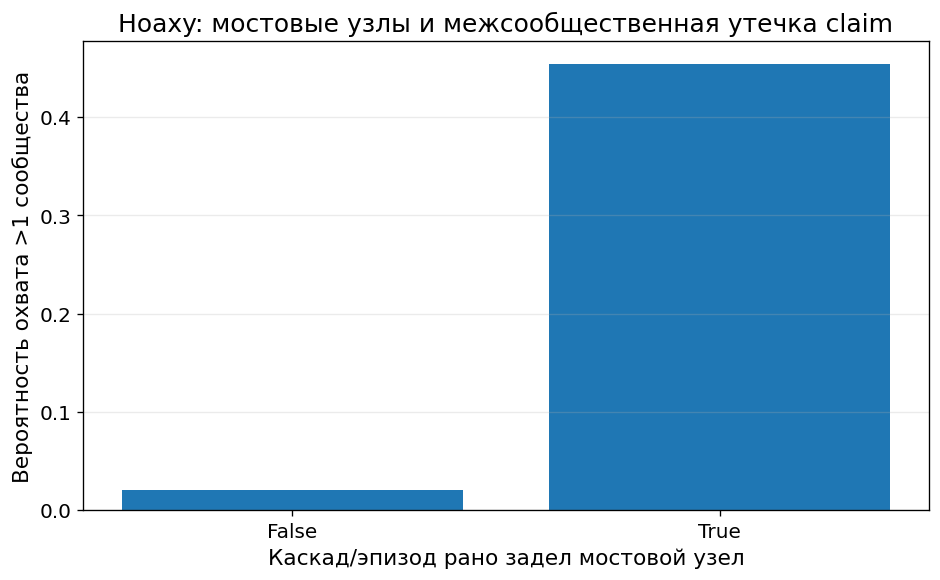

In [28]:
# ===== Cell 17. Real cascade / episode-level validation =====

# В Hoaxy-файле retweet.preelection.all.csv поле tweet_id не всегда является
# идентификатором полного каскада. В некоторых версиях данных это фактически
# идентификатор отдельного tweet/retweet-события, поэтому группировка только по
# tweet_id может дать одни singleton-группы и после фильтрации получится 0 каскадов.
#
# Поэтому ниже используется робастная логика:
# 1) сначала проверяем, есть ли достаточно повторяющихся tweet_id;
# 2) если есть — используем tweet_id как каскад;
# 3) если нет — строим эмпирические diffusion episodes: claim-события вокруг
#    одного endpoint-аккаунта внутри короткого временного окна.
#
# Это не подменяет полноценные URL/article-level каскады, которых в данном CSV
# может не быть, но дает воспроизводимую проверку главной гипотезы:
# раннее попадание claim-распространения в центральные/мостовые узлы связано
# с большим охватом и большей вероятностью межсообщественной утечки.

MIN_EVENTS_PER_CASCADE = 2
MIN_UNIQUE_USERS_PER_CASCADE = 2
MIN_TWEET_ID_CASCADES = 30
EPISODE_WINDOW = "12h"

analysis_nodes = set(UG_work.nodes())

# Собираем список мостовых узлов по размеченному G_work.
bridge_nodes_emp = set()
for u, v, d in G_work.edges(data=True):
    if d.get("edge_type") == "bridge":
        bridge_nodes_emp.add(u)
        bridge_nodes_emp.add(v)

pr_map = centrality_df.set_index("node")["pagerank"].to_dict()
deg_map = centrality_df.set_index("node")["degree"].to_dict()
core_map_emp = dict(core_number)

# Берем только claim/F-события, которые хотя бы одним концом касаются рабочего графа.
events_claim = events[events["state"] == "F"].copy()
events_claim = events_claim[
    events_claim["source"].isin(analysis_nodes) | events_claim["target"].isin(analysis_nodes)
].copy()

print("F events touching the working graph:", len(events_claim))

if events_claim.empty:
    print("Нет claim/F-событий, связанных с рабочим графом. Проверьте построение UG_work/G_work.")
    cascade_df = pd.DataFrame()
    early_pr_effect = pd.DataFrame()
    early_bridge_effect = pd.DataFrame()
    spearman_corr = pd.DataFrame()
else:
    # ----- Per-event topology features -----
    def get_community_or_nan(node):
        return UG_work.nodes[node]["community"] if node in analysis_nodes else np.nan

    events_claim["source_community"] = events_claim["source"].map(get_community_or_nan)
    events_claim["target_community"] = events_claim["target"].map(get_community_or_nan)

    events_claim["source_pagerank"] = events_claim["source"].map(pr_map).fillna(0.0)
    events_claim["target_pagerank"] = events_claim["target"].map(pr_map).fillna(0.0)
    events_claim["event_max_pagerank"] = events_claim[["source_pagerank", "target_pagerank"]].max(axis=1)

    events_claim["source_degree"] = events_claim["source"].map(deg_map).fillna(0.0)
    events_claim["target_degree"] = events_claim["target"].map(deg_map).fillna(0.0)
    events_claim["event_max_degree"] = events_claim[["source_degree", "target_degree"]].max(axis=1)

    events_claim["source_core"] = events_claim["source"].map(core_map_emp).fillna(0.0)
    events_claim["target_core"] = events_claim["target"].map(core_map_emp).fillna(0.0)
    events_claim["event_max_core"] = events_claim[["source_core", "target_core"]].max(axis=1)

    events_claim["touches_bridge_node"] = (
        events_claim["source"].isin(bridge_nodes_emp)
        | events_claim["target"].isin(bridge_nodes_emp)
    )

    # ----- Choose cascade identifier -----
    tweet_sizes = events_claim.groupby("tweet_id").size()
    repeated_tweet_cascades = int((tweet_sizes >= MIN_EVENTS_PER_CASCADE).sum())
    print(f"tweet_id groups with >= {MIN_EVENTS_PER_CASCADE} F events:", repeated_tweet_cascades)

    if repeated_tweet_cascades >= MIN_TWEET_ID_CASCADES:
        events_claim["cascade_id"] = "tweet:" + events_claim["tweet_id"].astype(str)
        cascade_mode = "tweet_id"
        center_col = None
        print("Cascade mode: tweet_id")
    else:
        # Fallback: source/target-centered temporal episodes.
        # Сравниваем оба endpoint-варианта и выбираем тот, который дает больше
        # неодноточечных claim-эпизодов.
        events_claim["time_bin"] = events_claim["timestamp"].dt.floor(EPISODE_WINDOW)

        candidate_rows = []
        for candidate_center, candidate_other in [("source", "target"), ("target", "source")]:
            tmp = events_claim[[candidate_center, candidate_other, "time_bin"]].copy()
            tmp["_episode_id"] = (
                candidate_center + ":" + tmp[candidate_center].astype(str)
                + "|bin:" + tmp["time_bin"].astype(str)
            )
            g = tmp.groupby("_episode_id").agg(
                n_events=(candidate_other, "size"),
                unique_other=(candidate_other, "nunique"),
            )
            eligible = g[
                (g["n_events"] >= MIN_EVENTS_PER_CASCADE)
                & (g["unique_other"] >= MIN_UNIQUE_USERS_PER_CASCADE)
            ]
            candidate_rows.append({
                "center_endpoint": candidate_center,
                "other_endpoint": candidate_other,
                "eligible_episodes": int(len(eligible)),
                "mean_events_in_eligible": float(eligible["n_events"].mean()) if len(eligible) else 0.0,
                "mean_unique_other_in_eligible": float(eligible["unique_other"].mean()) if len(eligible) else 0.0,
            })

        candidate_df = pd.DataFrame(candidate_rows)
        print("tweet_id не дает достаточно многособытийных каскадов; используем temporal episode fallback.")
        display(candidate_df)

        # Основной критерий — число пригодных эпизодов; вторичный — средний охват.
        candidate_df = candidate_df.sort_values(
            ["eligible_episodes", "mean_unique_other_in_eligible"],
            ascending=False,
        ).reset_index(drop=True)
        center_col = candidate_df.loc[0, "center_endpoint"]
        other_col = candidate_df.loc[0, "other_endpoint"]

        events_claim["cascade_id"] = (
            f"{center_col}:" + events_claim[center_col].astype(str)
            + "|bin:" + events_claim["time_bin"].astype(str)
        )
        cascade_mode = f"{center_col}-centered {EPISODE_WINDOW} episodes"
        print("Cascade mode:", cascade_mode)

    # ----- Aggregate cascade/episode features -----
    cascade_main = (
        events_claim
        .groupby("cascade_id")
        .agg(
            n_events=("tweet_id", "size"),
            unique_sources=("source", "nunique"),
            unique_targets=("target", "nunique"),
            first_time=("timestamp", "min"),
            last_time=("timestamp", "max"),
            touches_bridge_node=("touches_bridge_node", "max"),
            max_pagerank_anywhere=("event_max_pagerank", "max"),
            max_degree_anywhere=("event_max_degree", "max"),
            max_core_anywhere=("event_max_core", "max"),
        )
        .reset_index()
    )

    # Число уникальных пользователей в эпизоде считаем по обоим концам события.
    users_long = pd.concat([
        events_claim[["cascade_id", "source"]].rename(columns={"source": "user"}),
        events_claim[["cascade_id", "target"]].rename(columns={"target": "user"}),
    ], ignore_index=True)
    unique_users = users_long.groupby("cascade_id")["user"].nunique().rename("unique_users").reset_index()

    # Число затронутых сообществ тоже считаем по обоим концам, но только для узлов из рабочего графа.
    comm_long = pd.concat([
        events_claim[["cascade_id", "source_community"]].rename(columns={"source_community": "community"}),
        events_claim[["cascade_id", "target_community"]].rename(columns={"target_community": "community"}),
    ], ignore_index=True).dropna(subset=["community"])
    n_comms = comm_long.groupby("cascade_id")["community"].nunique().rename("n_communities").reset_index()

    cascade_main = cascade_main.merge(unique_users, on="cascade_id", how="left")
    cascade_main = cascade_main.merge(n_comms, on="cascade_id", how="left")
    cascade_main["unique_users"] = cascade_main["unique_users"].fillna(0).astype(int)
    cascade_main["n_communities"] = cascade_main["n_communities"].fillna(0).astype(int)

    cascade_main["duration_hours"] = (
        (cascade_main["last_time"] - cascade_main["first_time"]).dt.total_seconds() / 3600.0
    )
    cascade_main["cross_community"] = cascade_main["n_communities"] > 1
    cascade_main["log_unique_users"] = np.log1p(cascade_main["unique_users"])
    cascade_main["log_unique_targets"] = np.log1p(cascade_main["unique_targets"])
    cascade_main["cascade_mode"] = cascade_mode

    # Ранние признаки: первые 3 события каскада/эпизода.
    early_events = (
        events_claim
        .sort_values(["cascade_id", "timestamp"])
        .groupby("cascade_id")
        .head(3)
    )

    early_feats = (
        early_events
        .groupby("cascade_id")
        .agg(
            early_max_pagerank=("event_max_pagerank", "max"),
            early_max_degree=("event_max_degree", "max"),
            early_max_core=("event_max_core", "max"),
            early_bridge_touch=("touches_bridge_node", "max"),
        )
        .reset_index()
    )

    cascade_df = cascade_main.merge(early_feats, on="cascade_id", how="left")
    for col in ["early_max_pagerank", "early_max_degree", "early_max_core"]:
        cascade_df[col] = cascade_df[col].fillna(0.0)
    cascade_df["early_bridge_touch"] = cascade_df["early_bridge_touch"].fillna(False).astype(bool)

    # Убираем singleton-эпизоды, чтобы не смешивать настоящую диффузию с единичными событиями.
    cascade_df = cascade_df[
        (cascade_df["n_events"] >= MIN_EVENTS_PER_CASCADE)
        & (cascade_df["unique_users"] >= MIN_UNIQUE_USERS_PER_CASCADE)
    ].copy()

    pr_threshold_99 = centrality_df["pagerank"].quantile(0.99)
    cascade_df["early_top_1pct_pagerank"] = cascade_df["early_max_pagerank"] >= pr_threshold_99

    print("Number of F cascades/episodes after filtering:", len(cascade_df))
    print("Cascade mode used:", cascade_mode)
    display(cascade_df.head())
    cascade_df.to_csv(TABLE_DIR / "hoaxy_claim_cascade_features.csv", index=False)

    def compare_by_flag(df, flag_col):
        cols = [
            flag_col,
            "cascades",
            "mean_events",
            "median_events",
            "mean_unique_users",
            "median_unique_users",
            "mean_unique_targets",
            "mean_communities",
            "cross_community_prob",
            "mean_duration_hours",
        ]
        if df.empty or flag_col not in df.columns:
            return pd.DataFrame(columns=cols)
        out = (
            df.groupby(flag_col)
            .agg(
                cascades=("cascade_id", "size"),
                mean_events=("n_events", "mean"),
                median_events=("n_events", "median"),
                mean_unique_users=("unique_users", "mean"),
                median_unique_users=("unique_users", "median"),
                mean_unique_targets=("unique_targets", "mean"),
                mean_communities=("n_communities", "mean"),
                cross_community_prob=("cross_community", "mean"),
                mean_duration_hours=("duration_hours", "mean"),
            )
            .reset_index()
        )
        return out

    print("Early top-1% PageRank effect:")
    early_pr_effect = compare_by_flag(cascade_df, "early_top_1pct_pagerank")
    display(early_pr_effect)
    early_pr_effect.to_csv(TABLE_DIR / "hoaxy_cascade_early_pagerank_effect.csv", index=False)

    print("Early bridge-touch effect:")
    early_bridge_effect = compare_by_flag(cascade_df, "early_bridge_touch")
    display(early_bridge_effect)
    early_bridge_effect.to_csv(TABLE_DIR / "hoaxy_cascade_early_bridge_effect.csv", index=False)

    corr_cols = [
        "unique_users",
        "unique_targets",
        "n_communities",
        "early_max_pagerank",
        "early_max_degree",
        "early_max_core",
        "early_bridge_touch",
    ]

    if len(cascade_df) >= 3:
        spearman_corr = cascade_df[corr_cols].corr(method="spearman")
    else:
        spearman_corr = pd.DataFrame(np.nan, index=corr_cols, columns=corr_cols)

    print("Spearman correlations between early topology and cascade/episode size:")
    display(spearman_corr)
    spearman_corr.to_csv(TABLE_DIR / "hoaxy_cascade_spearman_correlations.csv")

    # ----- Plot 1: early influencer vs cascade/episode size -----
    if len(cascade_df) > 0 and cascade_df["early_top_1pct_pagerank"].nunique() >= 2:
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_data = [
            cascade_df.loc[~cascade_df["early_top_1pct_pagerank"], "log_unique_users"],
            cascade_df.loc[cascade_df["early_top_1pct_pagerank"], "log_unique_users"],
        ]
        ax.boxplot(plot_data, labels=["No early top-1% PR", "Early top-1% PR"], showfliers=False)
        ax.set_ylabel("log(1 + unique users)")
        ax.set_title("Hoaxy: раннее попадание в инфлюенсеров и размер claim-эпизода")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        fig.savefig(FIG_DIR / "hoaxy_cascade_early_influencer_size.png", bbox_inches="tight")
        plt.show()
    elif len(cascade_df) > 0:
        print("Недостаточно двух групп early_top_1pct_pagerank для boxplot; строим scatter вместо boxplot.")
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(cascade_df["early_max_pagerank"], cascade_df["log_unique_users"], alpha=0.25, s=12)
        ax.set_xlabel("Early max PageRank")
        ax.set_ylabel("log(1 + unique users)")
        ax.set_title("Hoaxy: ранний PageRank и размер claim-эпизода")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        fig.savefig(FIG_DIR / "hoaxy_cascade_early_influencer_size.png", bbox_inches="tight")
        plt.show()
    else:
        print("Нет каскадов/эпизодов для построения графика early influencer size.")

    # ----- Plot 2: early bridge touch vs cross-community diffusion -----
    bridge_comp = compare_by_flag(cascade_df, "early_bridge_touch")
    if len(bridge_comp) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        bridge_comp_plot = bridge_comp.sort_values("early_bridge_touch")
        ax.bar(bridge_comp_plot["early_bridge_touch"].astype(str), bridge_comp_plot["cross_community_prob"])
        ax.set_xlabel("Каскад/эпизод рано задел мостовой узел")
        ax.set_ylabel("Вероятность охвата >1 сообщества")
        ax.set_title("Hoaxy: мостовые узлы и межсообщественная утечка claim")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        fig.savefig(FIG_DIR / "hoaxy_cascade_bridge_cross_community.png", bbox_inches="tight")
        plt.show()
    else:
        print("Нет данных для графика bridge touch vs cross-community diffusion.")

# Часть II. Запуск исходной модели конкурентной перколяции на реальном Hoaxy-графе

До этого момента мы проверяли структуру реальных данных.  
Теперь усиливаем валидацию: запускаем ту же логику `S/F/C`, что была в исходной модели, но не на синтетической сети, а на реальной топологии Hoaxy.

Это позволяет получить:

- эмпирический аналог перколяционного порога `p_c`;
- сравнение стратегий fact-check посева на реальном графе;
- фазовую карту `p × r` на реальной сети;
- эксперимент с задержкой `delay` на реальной сети;
- out-of-sample temporal split: предсказывает ли ранняя центральность будущие claim-события.


## 18. Подготовка реального графа для динамических симуляций

Полный Hoaxy-граф слишком велик для многократных Монте-Карло запусков. Поэтому берётся высокосвязное ядро из `CONFIG["VALIDATION_NODES"]` узлов, затем оставляется его крупнейшая компонента.

Важно: это не новый синтетический граф. Это подграф реальной Hoaxy-сети с реальными весами, сообществами, мостами и центральностями.


In [23]:
# ===== Cell 18. Real Hoaxy graph for competitive-percolation validation =====

VAL_OUT = FIG_DIR

VALIDATION_NODES = CONFIG["VALIDATION_NODES"]
FAKE_SEED_POOL_N = CONFIG["FAKE_SEED_POOL_N"]

assert "UG_work" in globals(), "Сначала выполни ячейки построения UG_work / G_work / Louvain-сообществ."

weighted_degree_full = dict(UG_work.degree(weight="weight"))
validation_nodes = sorted(
    weighted_degree_full,
    key=weighted_degree_full.get,
    reverse=True,
)[:min(VALIDATION_NODES, UG_work.number_of_nodes())]

H_real = UG_work.subgraph(validation_nodes).copy()
H_real.remove_edges_from(nx.selfloop_edges(H_real))

if H_real.number_of_nodes() > 0:
    largest_component = max(nx.connected_components(H_real), key=len)
    H_real = H_real.subgraph(largest_component).copy()

# Нормируем веса ребер в диапазон [0.05, 1.0].
weights = []
for _, _, d in H_real.edges(data=True):
    w0 = float(d.get("weight", 1.0))
    if not np.isfinite(w0) or w0 <= 0:
        w0 = 1.0
    weights.append(w0)

w_max = max(weights) if weights else 1.0
for u, v, d in H_real.edges(data=True):
    w0 = float(d.get("weight", 1.0))
    if not np.isfinite(w0) or w0 <= 0:
        w0 = 1.0
    d["weight"] = float(np.clip(w0 / max(w_max, 1e-12), 0.05, 1.0))

# Проверяем, что у узлов есть community. Если нет — восстанавливаем из partition.
missing_communities = [n for n, d in H_real.nodes(data=True) if "community" not in d]
if missing_communities:
    nx.set_node_attributes(H_real, {n: partition.get(n, -1) for n in H_real.nodes()}, "community")

real_degree_dict = dict(H_real.degree(weight="weight"))
try:
    real_pagerank_dict = nx.pagerank(H_real, weight="weight", max_iter=1000)
except nx.PowerIterationFailedConvergence:
    total_degree = sum(real_degree_dict.values()) or 1.0
    real_pagerank_dict = {n: real_degree_dict[n] / total_degree for n in H_real.nodes()}

real_core_dict = nx.core_number(H_real)

real_nodes = np.array(list(H_real.nodes()), dtype=object)
real_node_to_idx = {node: i for i, node in enumerate(real_nodes)}
real_idx_to_node = {i: node for node, i in real_node_to_idx.items()}
N_real = len(real_nodes)

real_comm = np.array([H_real.nodes[n].get("community", -1) for n in real_nodes], dtype=object)
real_pagerank = np.array([real_pagerank_dict[n] for n in real_nodes], dtype=float)
real_degree = np.array([real_degree_dict[n] for n in real_nodes], dtype=float)
real_core = np.array([real_core_dict[n] for n in real_nodes], dtype=float)

real_bridge_node = np.zeros(N_real, dtype=bool)
real_bridge_edges = []
real_intra_edges = []

for u, v in H_real.edges():
    cu = H_real.nodes[u].get("community", -1)
    cv = H_real.nodes[v].get("community", -1)

    if cu == cv:
        real_intra_edges.append((u, v))
    else:
        real_bridge_edges.append((u, v))
        real_bridge_node[real_node_to_idx[u]] = True
        real_bridge_node[real_node_to_idx[v]] = True

# Быстрый список соседей для симулятора.
real_neighbors = [[] for _ in range(N_real)]
for u, v, d in H_real.edges(data=True):
    i = real_node_to_idx[u]
    j = real_node_to_idx[v]
    ww = float(d.get("weight", 1.0))
    real_neighbors[i].append((j, ww))
    real_neighbors[j].append((i, ww))

real_community_sizes = pd.Series(real_comm).value_counts().sort_values(ascending=False)
REAL_SOURCE_COMMUNITY = real_community_sizes.index[0]

# Пул реальных claim-активных узлов для старта F.
F_involved_nodes = set(events.loc[events["state"] == "F", "source"]) | set(events.loc[events["state"] == "F", "target"])
F_in_H = [n for n in F_involved_nodes if n in real_node_to_idx]
F_in_H_ranked = sorted(F_in_H, key=lambda n: real_pagerank_dict.get(n, 0.0), reverse=True)

if len(F_in_H_ranked) > 0:
    real_fake_seed_pool = np.array(
        [real_node_to_idx[n] for n in F_in_H_ranked[:FAKE_SEED_POOL_N]],
        dtype=int,
    )
else:
    real_fake_seed_pool = np.argsort(real_pagerank)[::-1][:FAKE_SEED_POOL_N].astype(int)

real_graph_summary = pd.DataFrame([
    {
        "nodes": H_real.number_of_nodes(),
        "edges": H_real.number_of_edges(),
        "communities": real_community_sizes.shape[0],
        "largest_community": REAL_SOURCE_COMMUNITY,
        "largest_community_size": int(real_community_sizes.iloc[0]),
        "bridge_edges": len(real_bridge_edges),
        "intra_edges": len(real_intra_edges),
        "bridge_edge_share": len(real_bridge_edges) / max(1, H_real.number_of_edges()),
        "bridge_nodes": int(real_bridge_node.sum()),
        "bridge_node_share": float(real_bridge_node.mean()),
        "fake_seed_pool": int(len(real_fake_seed_pool)),
        "mean_degree": float(np.mean([len(x) for x in real_neighbors])),
        "max_degree": int(np.max([len(x) for x in real_neighbors])),
    }
])

display(real_graph_summary)
display(real_community_sizes.head(10).rename_axis("community").reset_index(name="size"))

real_graph_summary.to_csv(TABLE_DIR / "hoaxy_real_validation_graph_summary.csv", index=False)


,nodes,edges,communities,largest_community,largest_community_size,bridge_edges,intra_edges,bridge_edge_share,bridge_nodes,bridge_node_share,fake_seed_pool,mean_degree,max_degree
0,7999,251173,7,177,5226,74868,176305,0.298073,7496,0.937117,500,62.8011,6303


,community,size
0,177,5226
1,225,1234
2,136,807
3,174,724
4,20,3
5,157,3
6,270,2


## 19. Competitive-percolation симулятор на реальном графе

Эта ячейка реализует ту же модельную логику, что и в исходной статье:

- `S = 0`, `F = 1`, `C = 2`;
- claim распространяется с вероятностью `min(1, p * w * edge_weight)`;
- fact-check распространяется с вероятностью `min(1, r * edge_weight)`;
- если узел получает оба давления одновременно, победитель выбирается пропорционально силе давления;
- переход `F → C` разрешён;
- переход `C → F` запрещён.

Отличие от синтетической модели: граф, веса, сообщества, мосты и центральности берутся из реального Hoaxy-графа.


In [24]:
# ===== Cell 19. Competitive percolation on the real Hoaxy graph =====

S, F, C = 0, 1, 2

REAL_STRATEGY_RU = {
    "none": "Без фактчека",
    "random": "Случайный узел",
    "same_community_random": "Случайный в исходном сообществе",
    "other_community_random": "Случайный в другом сообществе",
    "bridge": "Мостовой узел",
    "degree": "Макс. weighted degree",
    "high_degree": "Макс. weighted degree",
    "pagerank": "Макс. PageRank",
    "core": "Макс. k-core",
    "influencer": "Инфлюенсер исходного сообщества",
}


def _rng(seed_or_rng=None):
    if isinstance(seed_or_rng, np.random.Generator):
        return seed_or_rng
    return np.random.default_rng(seed_or_rng)


def _best_by_score(candidates, score_array):
    candidates = np.asarray(list(candidates), dtype=int)
    if len(candidates) == 0:
        return None
    return int(candidates[np.argmax(score_array[candidates])])


def choose_real_fake_seed(fake_community=None, rng=None, top_k=50):
    """
    Фейк стартует у эмпирически claim-активного центрального узла.
    Если fake_community задано, выбираем из этого сообщества; иначе — из общего пула claim-активных узлов.
    """
    rng = _rng(rng)

    if fake_community is None:
        candidates = real_fake_seed_pool
    else:
        candidates = real_fake_seed_pool[real_comm[real_fake_seed_pool] == fake_community]
        if len(candidates) == 0:
            candidates = np.where(real_comm == fake_community)[0]
        if len(candidates) == 0:
            candidates = real_fake_seed_pool

    ordered = candidates[np.argsort(real_pagerank[candidates])[::-1]]
    top = ordered[:min(top_k, len(ordered))]
    return int(rng.choice(top))


def choose_real_check_seed(strategy, fake_seed_idx, fake_community=None, rng=None):
    """
    Стратегии запуска fact-check на реальном Hoaxy-графе.
    Возвращает индекс узла в real_nodes или None.
    """
    rng = _rng(rng)

    if strategy is None or strategy == "none":
        return None

    if fake_community is None:
        fake_community = real_comm[fake_seed_idx]

    all_nodes = np.arange(N_real)
    pool = all_nodes[all_nodes != fake_seed_idx]

    if len(pool) == 0:
        return None

    if strategy == "random":
        return int(rng.choice(pool))

    if strategy == "same_community_random":
        candidates = pool[real_comm[pool] == fake_community]
        if len(candidates) == 0:
            candidates = pool
        return int(rng.choice(candidates))

    if strategy == "other_community_random":
        candidates = pool[real_comm[pool] != fake_community]
        if len(candidates) == 0:
            candidates = pool
        return int(rng.choice(candidates))

    if strategy == "bridge":
        candidates = pool[(real_bridge_node[pool]) & (real_comm[pool] == fake_community)]
        if len(candidates) == 0:
            candidates = pool[real_bridge_node[pool]]
        if len(candidates) == 0:
            candidates = pool
        return _best_by_score(candidates, real_degree)

    if strategy in {"degree", "high_degree"}:
        return _best_by_score(pool, real_degree)

    if strategy == "pagerank":
        return _best_by_score(pool, real_pagerank)

    if strategy == "core":
        candidates = pool[real_core[pool] == np.max(real_core[pool])]
        return _best_by_score(candidates, real_pagerank)

    if strategy == "influencer":
        candidates = pool[real_comm[pool] == fake_community]
        if len(candidates) == 0:
            candidates = pool
        return _best_by_score(candidates, real_pagerank)

    raise ValueError(f"Unknown strategy: {strategy}")


def run_real_competitive_percolation(
    fake_seed_idx,
    check_seed_idx=None,
    p=0.03,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    outbreak_threshold=0.25,
    check_spread_factor=1.0,
    check_conversion_factor=1.0,
    seed=42,
):
    """
    Independent cascade / competitive percolation на реальном Hoaxy-графе.
    """
    rng = np.random.default_rng(seed)

    states = np.zeros(N_real, dtype=np.int8)
    ever_fake = np.zeros(N_real, dtype=bool)

    active_fake = set()
    active_check = set()

    if fake_seed_idx is not None:
        fake_seed_idx = int(fake_seed_idx)
        states[fake_seed_idx] = F
        ever_fake[fake_seed_idx] = True
        active_fake.add(fake_seed_idx)

    origin_comm = real_comm[fake_seed_idx] if fake_seed_idx is not None else None

    if check_seed_idx is not None and delay == 0:
        check_seed_idx = int(check_seed_idx)
        states[check_seed_idx] = C
        active_check.add(check_seed_idx)
        active_fake.discard(check_seed_idx)

    history_rows = []

    def record(t):
        fake_count = int(np.sum(states == F))
        checked_count = int(np.sum(states == C))
        susceptible_count = int(np.sum(states == S))
        ever_fake_count = int(np.sum(ever_fake))

        history_rows.append({
            "t": t,
            "susceptible": susceptible_count,
            "fake": fake_count,
            "checked": checked_count,
            "ever_fake": ever_fake_count,
            "susceptible_share": susceptible_count / N_real,
            "fake_share": fake_count / N_real,
            "checked_share": checked_count / N_real,
            "ever_fake_share": ever_fake_count / N_real,
        })

    record(0)

    for t in range(1, steps + 1):
        if check_seed_idx is not None and t == delay:
            check_seed_idx = int(check_seed_idx)
            states[check_seed_idx] = C
            active_check.add(check_seed_idx)
            active_fake.discard(check_seed_idx)

        fake_pressure = defaultdict(float)
        check_pressure = defaultdict(float)

        for u in list(active_fake):
            if states[u] != F:
                continue
            for v, edge_weight in real_neighbors[u]:
                if states[v] == C:
                    continue
                prob = min(1.0, p * w * edge_weight)
                if rng.random() < prob:
                    fake_pressure[v] += prob

        for u in list(active_check):
            if states[u] != C:
                continue
            for v, edge_weight in real_neighbors[u]:
                if states[v] == C:
                    continue
                factor = check_conversion_factor if states[v] == F else check_spread_factor
                prob = min(1.0, r * factor * edge_weight)
                if rng.random() < prob:
                    check_pressure[v] += prob

        new_fake = set()
        new_check = set()
        targets = set(fake_pressure.keys()) | set(check_pressure.keys())

        for v in targets:
            if states[v] == C:
                continue

            f_press = fake_pressure.get(v, 0.0)
            c_press = check_pressure.get(v, 0.0)

            if states[v] == F:
                if c_press > 0:
                    states[v] = C
                    new_check.add(v)
                continue

            if f_press > 0 and c_press > 0:
                check_win_prob = c_press / (f_press + c_press)
                if rng.random() < check_win_prob:
                    states[v] = C
                    new_check.add(v)
                else:
                    states[v] = F
                    ever_fake[v] = True
                    new_fake.add(v)
            elif f_press > 0:
                states[v] = F
                ever_fake[v] = True
                new_fake.add(v)
            elif c_press > 0:
                states[v] = C
                new_check.add(v)

        active_fake = new_fake
        active_check = new_check
        record(t)

    history = pd.DataFrame(history_rows)
    peak_idx = int(history["fake_share"].idxmax())

    if origin_comm is None:
        outside_origin_ever_share = np.nan
        communities_reached = np.nan
        communities_reached_share = np.nan
    else:
        outside_origin_ever_share = float(np.mean(ever_fake & (real_comm != origin_comm)))
        communities_reached = int(len(np.unique(real_comm[ever_fake]))) if ever_fake.any() else 0
        communities_reached_share = communities_reached / max(1, len(np.unique(real_comm)))

    metrics = {
        "final_fake_share": float(history["fake_share"].iloc[-1]),
        "ever_fake_share": float(history["ever_fake_share"].iloc[-1]),
        "final_checked_share": float(history["checked_share"].iloc[-1]),
        "peak_fake_share": float(history["fake_share"].max()),
        "time_to_peak": int(history.loc[peak_idx, "t"]),
        "outbreak": int(history["ever_fake_share"].iloc[-1] >= outbreak_threshold),
        "outside_origin_ever_share": outside_origin_ever_share,
        "communities_reached": communities_reached,
        "communities_reached_share": communities_reached_share,
        "fake_seed_idx": int(fake_seed_idx) if fake_seed_idx is not None else None,
        "check_seed_idx": int(check_seed_idx) if check_seed_idx is not None else None,
        "fake_seed_user_id": real_idx_to_node.get(int(fake_seed_idx), None) if fake_seed_idx is not None else None,
        "check_seed_user_id": real_idx_to_node.get(int(check_seed_idx), None) if check_seed_idx is not None else None,
        "p": p,
        "w": w,
        "r": r,
        "delay": delay,
    }

    return {"history": history, "states": states, "ever_fake": ever_fake, "metrics": metrics}


def run_real_many(
    strategy="influencer",
    n_runs=50,
    p=0.03,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    outbreak_threshold=0.25,
    fake_community=None,
    fake_seed_indices=None,
    seed=42,
    show_progress=True,
):
    rng = np.random.default_rng(seed)
    rows = []

    if fake_seed_indices is None:
        fake_seed_indices = [
            choose_real_fake_seed(fake_community=fake_community, rng=rng)
            for _ in range(n_runs)
        ]
    else:
        fake_seed_indices = list(fake_seed_indices)
        n_runs = len(fake_seed_indices)

    iterator = range(n_runs)
    if show_progress:
        iterator = tqdm(iterator, desc=f"Hoaxy strategy={strategy}", leave=False)

    for run in iterator:
        run_seed = int(rng.integers(1, 1_000_000_000))
        run_rng = np.random.default_rng(run_seed)

        fake_seed_idx = int(fake_seed_indices[run])
        fc = real_comm[fake_seed_idx] if fake_community is None else fake_community

        check_seed_idx = choose_real_check_seed(
            strategy=strategy,
            fake_seed_idx=fake_seed_idx,
            fake_community=fc,
            rng=run_rng,
        )

        sim = run_real_competitive_percolation(
            fake_seed_idx=fake_seed_idx,
            check_seed_idx=check_seed_idx,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            outbreak_threshold=outbreak_threshold,
            seed=run_seed,
        )

        row = sim["metrics"].copy()
        row["run"] = run
        row["strategy"] = strategy
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_real_strategy_results(results_df):
    summary = (
        results_df
        .groupby("strategy", as_index=False)
        .agg(
            runs=("run", "count"),
            outbreak_probability=("outbreak", "mean"),
            mean_final_fake_share=("final_fake_share", "mean"),
            sem_final_fake_share=("final_fake_share", "sem"),
            mean_ever_fake_share=("ever_fake_share", "mean"),
            sem_ever_fake_share=("ever_fake_share", "sem"),
            mean_final_checked_share=("final_checked_share", "mean"),
            mean_peak_fake_share=("peak_fake_share", "mean"),
            mean_time_to_peak=("time_to_peak", "mean"),
            mean_outside_origin_ever_share=("outside_origin_ever_share", "mean"),
            mean_communities_reached=("communities_reached", "mean"),
        )
    )

    summary["strategy_ru"] = summary["strategy"].map(REAL_STRATEGY_RU).fillna(summary["strategy"])
    return summary.sort_values("mean_ever_fake_share").reset_index(drop=True)


print("Simulator is ready. N_real =", N_real)


Simulator is ready. N_real = 7999


## 20. Эмпирический перколяционный порог `p_c` на реальном графе

Сначала fact-check отключается (`strategy="none"`, `r=0`), и мы сканируем разные значения `p`.  
Эмпирический `p_c` определяется так же, как в статье: минимальное `p`, при котором вероятность инфодемии становится не меньше 0.5.

Инфодемия фиксируется по накопительной метрике:

\[
\text{ever\_fake\_share} \geq \theta, \quad \theta = 0.25.
\]


Hoaxy empirical p_c scan:   0%|          | 0/16 [00:00<?, ?it/s]

Estimated empirical p_c on Hoaxy graph: 0.015


,p,runs,outbreak_probability,mean_ever_fake_share,mean_peak_fake_share,mean_final_fake_share
0,0.005,30,0.0,0.026570,0.026570,0.026570
1,0.010,30,0.0,0.209755,0.209755,0.209755
2,0.015,30,1.0,0.334417,0.334417,0.334417
3,0.020,30,1.0,0.441839,0.441839,0.441839
4,0.025,30,1.0,0.526103,0.526103,0.526103
5,0.030,30,1.0,0.599296,0.599296,0.599296
6,0.035,30,1.0,0.658570,0.658570,0.658570
7,0.040,30,1.0,0.707680,0.707680,0.707680
8,0.045,30,1.0,0.748235,0.748235,0.748235
9,0.050,30,1.0,0.783273,0.783273,0.783273


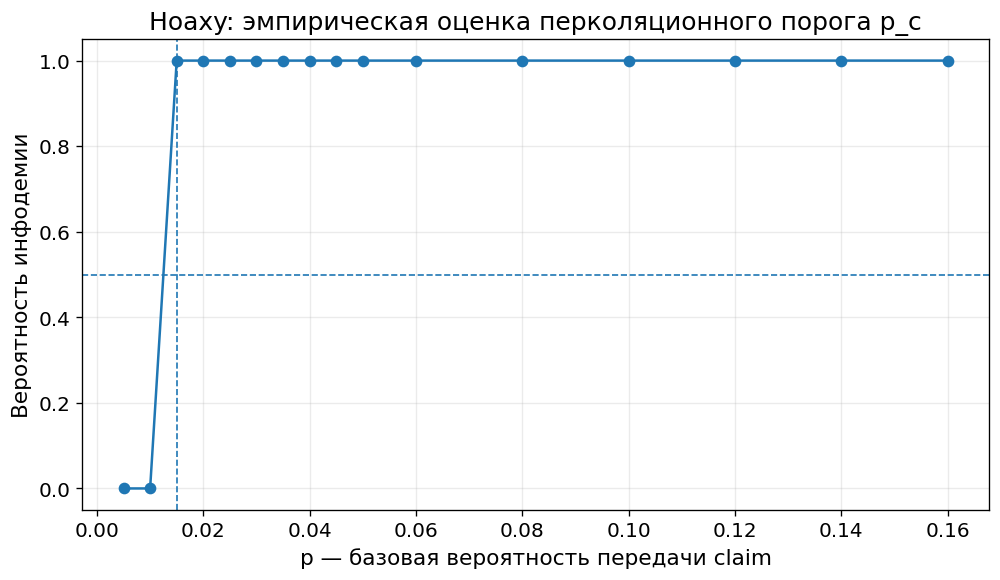

In [25]:
# ===== Cell 20. Empirical p_c on the real Hoaxy graph without fact-checking =====

REAL_OUTBREAK_THRESHOLD = 0.25
REAL_STEPS = 30
REAL_W = 2.0
REAL_DELAY = 3
REAL_PC_RUNS = CONFIG["REAL_PC_RUNS"]
REAL_P_VALUES = np.round(np.r_[np.linspace(0.005, 0.05, 10), np.linspace(0.06, 0.16, 6)], 4)

pc_rows = []

for p_val in tqdm(REAL_P_VALUES, desc="Hoaxy empirical p_c scan"):
    df_p = run_real_many(
        strategy="none",
        n_runs=REAL_PC_RUNS,
        p=float(p_val),
        w=REAL_W,
        r=0.0,
        delay=REAL_DELAY,
        steps=REAL_STEPS,
        outbreak_threshold=REAL_OUTBREAK_THRESHOLD,
        seed=SEED + int(100000 * p_val),
        show_progress=False,
    )

    pc_rows.append({
        "p": float(p_val),
        "runs": len(df_p),
        "outbreak_probability": df_p["outbreak"].mean(),
        "mean_ever_fake_share": df_p["ever_fake_share"].mean(),
        "mean_peak_fake_share": df_p["peak_fake_share"].mean(),
        "mean_final_fake_share": df_p["final_fake_share"].mean(),
    })

real_pc_scan = pd.DataFrame(pc_rows)

crossing = real_pc_scan.loc[real_pc_scan["outbreak_probability"] >= 0.5]
if len(crossing) > 0:
    REAL_PC = float(crossing["p"].iloc[0])
else:
    closest_idx = (real_pc_scan["outbreak_probability"] - 0.5).abs().idxmin()
    REAL_PC = float(real_pc_scan.loc[closest_idx, "p"])

REAL_P_FOR_VALIDATION = REAL_PC

print("Estimated empirical p_c on Hoaxy graph:", REAL_PC)
display(real_pc_scan)
real_pc_scan.to_csv(TABLE_DIR / "hoaxy_empirical_pc_scan.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(real_pc_scan["p"], real_pc_scan["outbreak_probability"], marker="o")
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.axvline(REAL_PC, linestyle="--", linewidth=1)
ax.set_xlabel("p — базовая вероятность передачи claim")
ax.set_ylabel("Вероятность инфодемии")
ax.set_title("Hoaxy: эмпирическая оценка перколяционного порога p_c")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_empirical_pc.png", bbox_inches="tight")
plt.show()


## 21. Сравнение стратегий fact-check на реальном графе

Теперь исходная модель запускается на реальной Hoaxy-топологии при `p ≈ p_c`.  
Сравниваются стратегии посева fact-check:

- отсутствие fact-check;
- случайный узел;
- случайный узел в исходном сообществе;
- случайный узел в другом сообществе;
- мостовой узел;
- узел с высокой degree;
- узел с высоким PageRank;
- узел из максимального k-core;
- инфлюенсер в исходном сообществе.

Для честного сравнения все стратегии получают один и тот же набор стартовых fake-seeds.


Hoaxy strategy validation:   0%|          | 0/9 [00:00<?, ?it/s]

,strategy_ru,runs,outbreak_probability,mean_final_fake_share,mean_ever_fake_share,mean_peak_fake_share,mean_final_checked_share,mean_outside_origin_ever_share,mean_communities_reached,ever_reduction_vs_none_pct,outbreak_reduction_vs_none_pct
0,Макс. weighted degree,60,0.000000,0.000185,0.040049,0.034125,0.986923,0.018779,3.566667,88.112437,100.000000
1,Макс. PageRank,60,0.000000,0.000231,0.042543,0.035348,0.987067,0.018536,3.633333,87.372132,100.000000
2,Макс. k-core,60,0.000000,0.000183,0.044068,0.036467,0.987328,0.019871,3.600000,86.919414,100.000000
3,Инфлюенсер исходного сообщества,60,0.000000,0.000217,0.054107,0.042599,0.987213,0.023280,3.566667,83.939638,100.000000
4,Мостовой узел,60,0.000000,0.000271,0.059062,0.046983,0.986759,0.025684,3.733333,82.468922,100.000000
5,Случайный в исходном сообществе,60,0.000000,0.000585,0.114685,0.083510,0.986975,0.049565,4.183333,65.958315,100.000000
6,Случайный узел,60,0.050000,0.000579,0.123311,0.091901,0.986973,0.055986,4.133333,63.397860,95.000000
7,Случайный в другом сообществе,60,0.066667,0.000565,0.131381,0.101019,0.987036,0.053715,4.183333,61.002536,93.333333
8,Без фактчека,60,1.000000,0.336896,0.336896,0.336896,0.000000,0.133112,4.666667,0.000000,0.000000


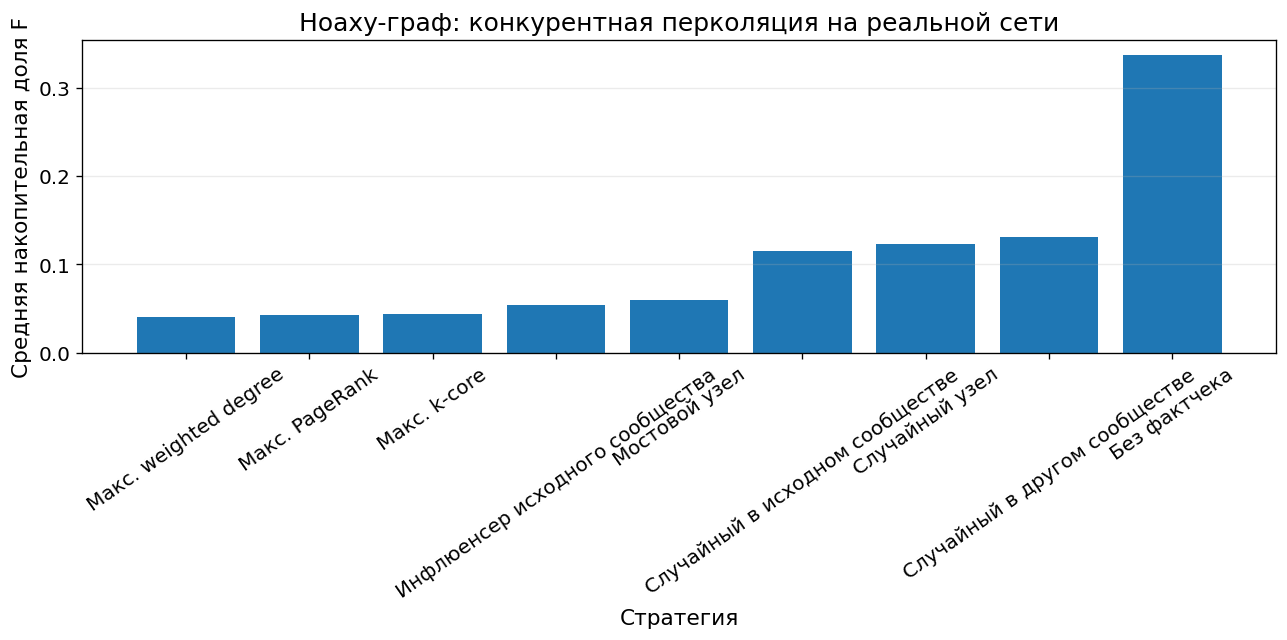

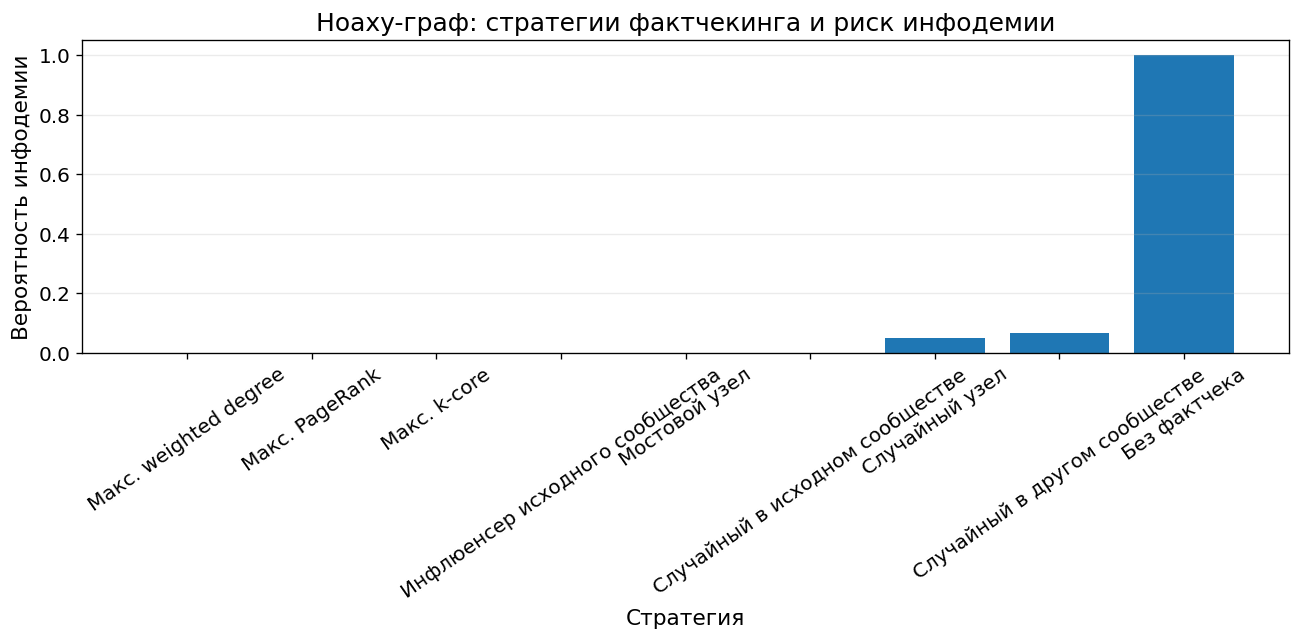

In [26]:
# ===== Cell 21. Strategy comparison: original model on the real Hoaxy graph =====

REAL_STRATEGIES = [
    "none",
    "random",
    "same_community_random",
    "other_community_random",
    "bridge",
    "high_degree",
    "pagerank",
    "core",
    "influencer",
]

REAL_STRATEGY_RUNS = CONFIG["REAL_STRATEGY_RUNS"]
REAL_R_FOR_VALIDATION = 0.35

# Общий набор fake-seeds для всех стратегий.
strategy_seed_rng = np.random.default_rng(SEED + 7000)
shared_fake_seeds_strategy = [
    choose_real_fake_seed(rng=strategy_seed_rng)
    for _ in range(REAL_STRATEGY_RUNS)
]

real_strategy_parts = []

for s_idx, strategy in enumerate(tqdm(REAL_STRATEGIES, desc="Hoaxy strategy validation")):
    part = run_real_many(
        strategy=strategy,
        n_runs=REAL_STRATEGY_RUNS,
        p=REAL_P_FOR_VALIDATION,
        w=REAL_W,
        r=REAL_R_FOR_VALIDATION,
        delay=REAL_DELAY,
        steps=REAL_STEPS,
        outbreak_threshold=REAL_OUTBREAK_THRESHOLD,
        fake_seed_indices=shared_fake_seeds_strategy,
        seed=SEED + 7100 + s_idx,
        show_progress=False,
    )
    real_strategy_parts.append(part)

real_strategy_results = pd.concat(real_strategy_parts, ignore_index=True)
real_strategy_summary = summarize_real_strategy_results(real_strategy_results)

baseline_ever = float(
    real_strategy_summary.loc[
        real_strategy_summary["strategy"] == "none",
        "mean_ever_fake_share",
    ].iloc[0]
)

baseline_outbreak = float(
    real_strategy_summary.loc[
        real_strategy_summary["strategy"] == "none",
        "outbreak_probability",
    ].iloc[0]
)

real_strategy_summary["ever_reduction_vs_none_pct"] = 100 * (
    1 - real_strategy_summary["mean_ever_fake_share"] / max(baseline_ever, 1e-12)
)
real_strategy_summary["outbreak_reduction_vs_none_pct"] = 100 * (
    1 - real_strategy_summary["outbreak_probability"] / max(baseline_outbreak, 1e-12)
)

cols = [
    "strategy_ru",
    "runs",
    "outbreak_probability",
    "mean_final_fake_share",
    "mean_ever_fake_share",
    "mean_peak_fake_share",
    "mean_final_checked_share",
    "mean_outside_origin_ever_share",
    "mean_communities_reached",
    "ever_reduction_vs_none_pct",
    "outbreak_reduction_vs_none_pct",
]

display(real_strategy_summary[cols])
real_strategy_summary.to_csv(TABLE_DIR / "hoaxy_real_graph_strategy_summary.csv", index=False)
real_strategy_results.to_csv(TABLE_DIR / "hoaxy_real_graph_strategy_runs.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = real_strategy_summary.sort_values("mean_ever_fake_share")
ax.bar(plot_df["strategy_ru"], plot_df["mean_ever_fake_share"])
ax.set_ylabel("Средняя накопительная доля F")
ax.set_xlabel("Стратегия")
ax.set_title("Hoaxy-граф: конкурентная перколяция на реальной сети")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_strategy_ever_fake.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = real_strategy_summary.sort_values("outbreak_probability")
ax.bar(plot_df["strategy_ru"], plot_df["outbreak_probability"])
ax.set_ylabel("Вероятность инфодемии")
ax.set_xlabel("Стратегия")
ax.set_title("Hoaxy-граф: стратегии фактчекинга и риск инфодемии")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_strategy_outbreak.png", bbox_inches="tight")
plt.show()


## 22. Фазовая карта `p × r` на реальном Hoaxy-графе

Это прямой аналог фазовой карты из синтетической части статьи, но теперь на реальной топологии.

На сетке значений `p` и `r` оцениваются:

- вероятность инфодемии;
- средний финальный остаток `F`;
- эмпирический `p_c(r)`.

Если с ростом `r` область инфодемии сдвигается вправо, значит модельный вывод о fact-check как механизме повышения перколяционного порога сохраняется на реальном графе.


Hoaxy p × r phase map:   0%|          | 0/49 [00:00<?, ?it/s]

,p,r,strategy,runs,outbreak_probability,mean_final_fake_share,mean_ever_fake_share,mean_peak_fake_share
0,0.0082,0.05,influencer,20,0.00,0.008432,0.022515,0.017208
1,0.0112,0.05,influencer,20,0.00,0.025903,0.059501,0.042299
2,0.0142,0.05,influencer,20,0.00,0.059457,0.133079,0.093387
3,0.0173,0.05,influencer,20,0.15,0.080754,0.174734,0.122940
4,0.0202,0.05,influencer,20,0.75,0.136686,0.305419,0.221928


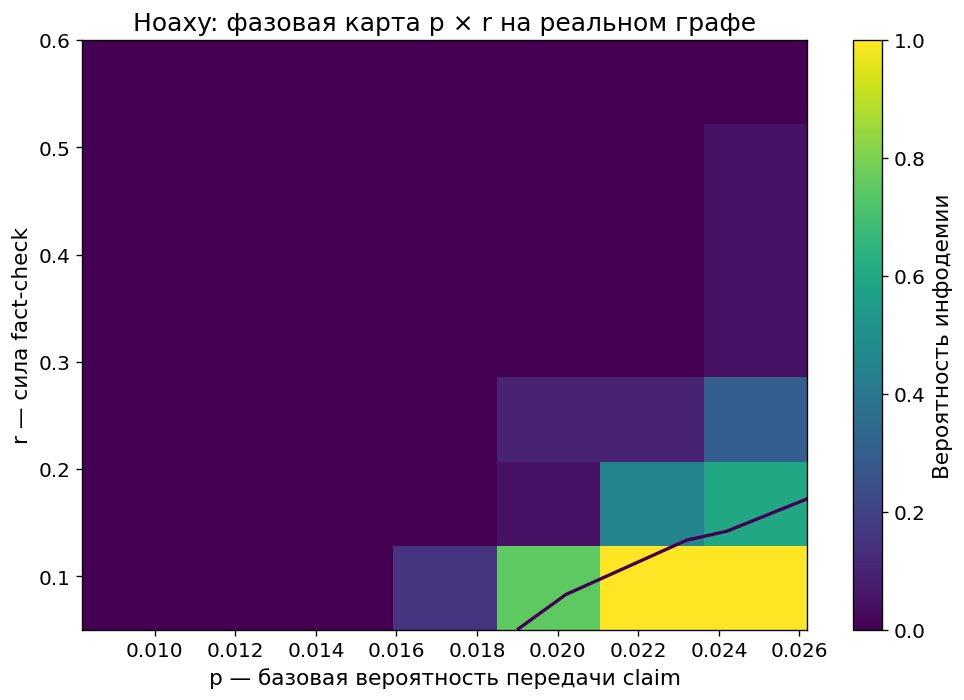

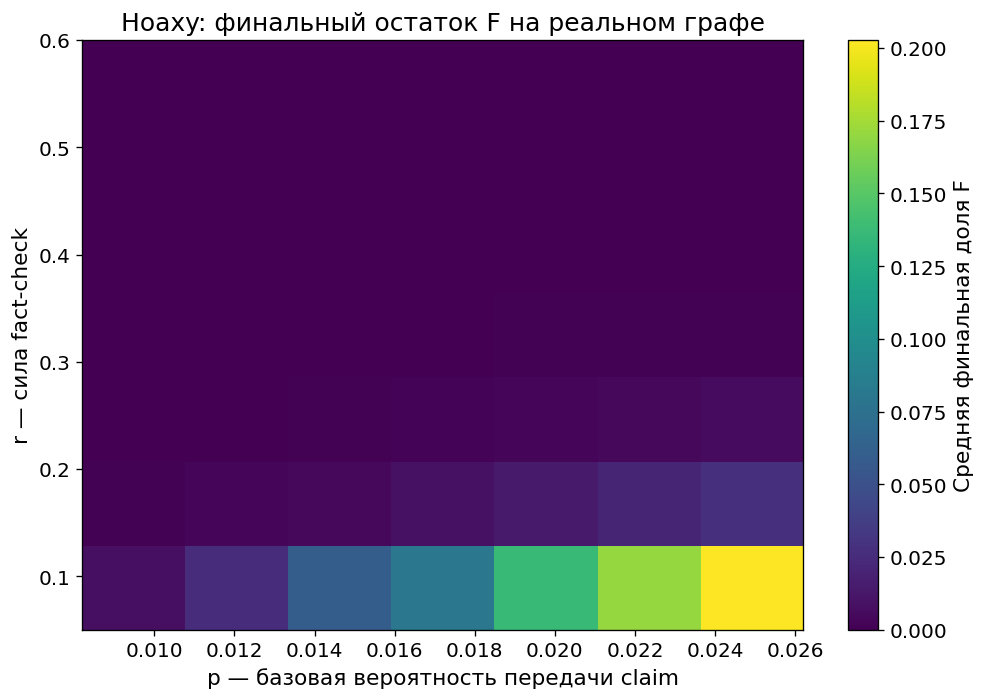

,r,empirical_pc
0,0.050,0.0202
1,0.142,0.0262
2,0.233,NaN
3,0.325,NaN
4,0.417,NaN
5,0.508,NaN
6,0.600,NaN


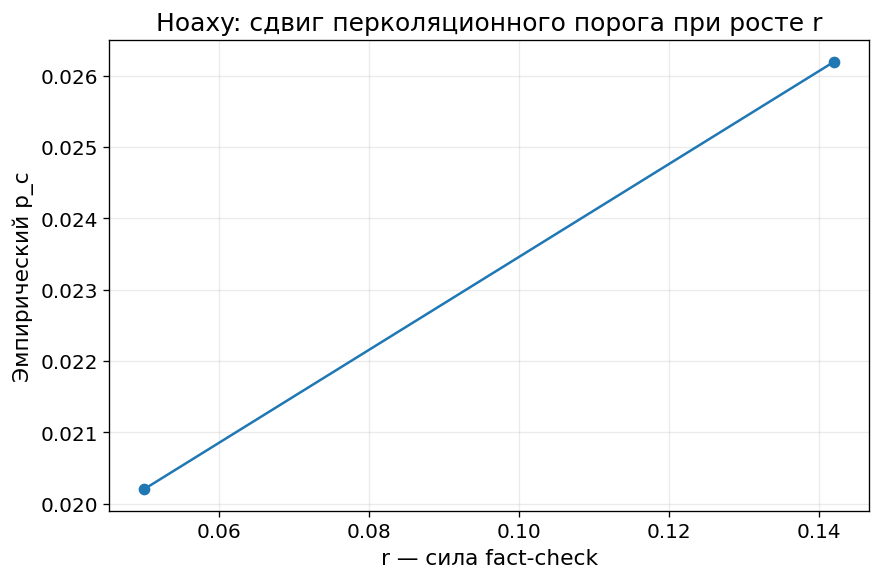

In [27]:
# ===== Cell 22. Hoaxy p × r phase map on the real graph =====


def scan_real_p_r_grid(
    p_values,
    r_values,
    strategy="influencer",
    n_runs=20,
    w=2.0,
    delay=3,
    steps=30,
    outbreak_threshold=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    rows = []

    total = len(p_values) * len(r_values)
    pbar = tqdm(total=total, desc="Hoaxy p × r phase map")

    for r_val in r_values:
        for p_val in p_values:
            df = run_real_many(
                strategy=strategy,
                n_runs=n_runs,
                p=float(p_val),
                w=w,
                r=float(r_val),
                delay=delay,
                steps=steps,
                outbreak_threshold=outbreak_threshold,
                seed=int(rng.integers(1, 1_000_000_000)),
                show_progress=False,
            )

            rows.append({
                "p": float(p_val),
                "r": float(r_val),
                "strategy": strategy,
                "runs": n_runs,
                "outbreak_probability": df["outbreak"].mean(),
                "mean_final_fake_share": df["final_fake_share"].mean(),
                "mean_ever_fake_share": df["ever_fake_share"].mean(),
                "mean_peak_fake_share": df["peak_fake_share"].mean(),
            })
            pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


REAL_PR_GRID = CONFIG["REAL_PR_GRID"]
REAL_PR_RUNS = CONFIG["REAL_PR_RUNS"]

p_low = max(0.002, REAL_P_FOR_VALIDATION * 0.55)
p_high = max(p_low + 0.005, min(0.25, REAL_P_FOR_VALIDATION * 1.75))

REAL_PR_P_VALUES = np.round(np.linspace(p_low, p_high, REAL_PR_GRID), 4)
REAL_PR_R_VALUES = np.round(np.linspace(0.05, 0.60, REAL_PR_GRID), 3)

real_pr_df = scan_real_p_r_grid(
    p_values=REAL_PR_P_VALUES,
    r_values=REAL_PR_R_VALUES,
    strategy="influencer",
    n_runs=REAL_PR_RUNS,
    w=REAL_W,
    delay=REAL_DELAY,
    steps=REAL_STEPS,
    outbreak_threshold=REAL_OUTBREAK_THRESHOLD,
    seed=SEED + 9000,
)

display(real_pr_df.head())
real_pr_df.to_csv(TABLE_DIR / "hoaxy_real_graph_phase_pr_grid.csv", index=False)

prob_matrix = real_pr_df.pivot(index="r", columns="p", values="outbreak_probability")
final_matrix = real_pr_df.pivot(index="r", columns="p", values="mean_final_fake_share")

fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(
    prob_matrix.values,
    origin="lower",
    aspect="auto",
    extent=[
        REAL_PR_P_VALUES.min(),
        REAL_PR_P_VALUES.max(),
        REAL_PR_R_VALUES.min(),
        REAL_PR_R_VALUES.max(),
    ],
    vmin=0,
    vmax=1,
)
try:
    ax.contour(REAL_PR_P_VALUES, REAL_PR_R_VALUES, prob_matrix.values, levels=[0.5], linewidths=2)
except Exception as e:
    print("Contour skipped:", e)
ax.set_xlabel("p — базовая вероятность передачи claim")
ax.set_ylabel("r — сила fact-check")
ax.set_title("Hoaxy: фазовая карта p × r на реальном графе")
fig.colorbar(im, ax=ax, label="Вероятность инфодемии")
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_phase_pr_outbreak.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(
    final_matrix.values,
    origin="lower",
    aspect="auto",
    extent=[
        REAL_PR_P_VALUES.min(),
        REAL_PR_P_VALUES.max(),
        REAL_PR_R_VALUES.min(),
        REAL_PR_R_VALUES.max(),
    ],
)
ax.set_xlabel("p — базовая вероятность передачи claim")
ax.set_ylabel("r — сила fact-check")
ax.set_title("Hoaxy: финальный остаток F на реальном графе")
fig.colorbar(im, ax=ax, label="Средняя финальная доля F")
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_phase_pr_final.png", bbox_inches="tight")
plt.show()

real_pc_by_r_rows = []
for r_val, part in real_pr_df.groupby("r"):
    part = part.sort_values("p")
    crossing = part.loc[part["outbreak_probability"] >= 0.5]
    pc_val = float(crossing["p"].iloc[0]) if len(crossing) > 0 else np.nan
    real_pc_by_r_rows.append({"r": float(r_val), "empirical_pc": pc_val})

real_pc_by_r = pd.DataFrame(real_pc_by_r_rows)
display(real_pc_by_r)
real_pc_by_r.to_csv(TABLE_DIR / "hoaxy_real_graph_pc_by_r.csv", index=False)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(real_pc_by_r["r"], real_pc_by_r["empirical_pc"], marker="o")
ax.set_xlabel("r — сила fact-check")
ax.set_ylabel("Эмпирический p_c")
ax.set_title("Hoaxy: сдвиг перколяционного порога при росте r")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_pc_by_r.png", bbox_inches="tight")
plt.show()


## 23. Эффект задержки `delay` на реальном графе

Этот эксперимент проверяет, сохраняется ли ключевой вывод исходной модели на реальной топологии: поздний fact-check может снизить финальный остаток `F`, но не успевает предотвратить ранний пик и накопительный охват.


Hoaxy delay validation:   0%|          | 0/7 [00:00<?, ?it/s]

,delay,runs,outbreak_probability,mean_final_fake_share,sem_final_fake_share,mean_ever_fake_share,sem_ever_fake_share,mean_peak_fake_share,sem_peak_fake_share,mean_final_checked_share,mean_outside_origin_ever_share
0,0,60,0.000000,0.000019,0.000006,0.003694,0.000506,0.003232,0.000439,0.986984,0.001308
1,1,60,0.000000,0.000013,0.000005,0.003659,0.000445,0.003255,0.000417,0.987190,0.001290
2,2,60,0.000000,0.000177,0.000025,0.020553,0.002067,0.015698,0.001656,0.987188,0.008824
3,3,60,0.000000,0.000275,0.000028,0.055847,0.004151,0.043920,0.003465,0.986911,0.022230
4,5,60,0.216667,0.000750,0.000048,0.199535,0.008145,0.162870,0.006869,0.987242,0.079689
5,8,60,1.000000,0.000958,0.000043,0.327631,0.001263,0.313220,0.002244,0.986594,0.129885
6,12,60,1.000000,0.001083,0.000055,0.337071,0.000844,0.336692,0.000873,0.987215,0.133667


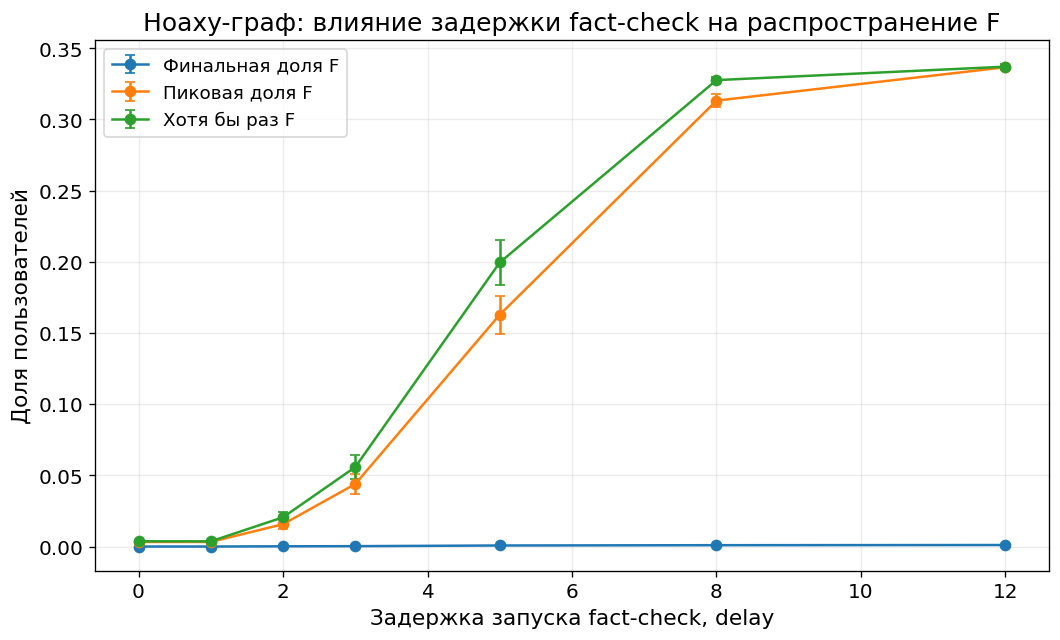

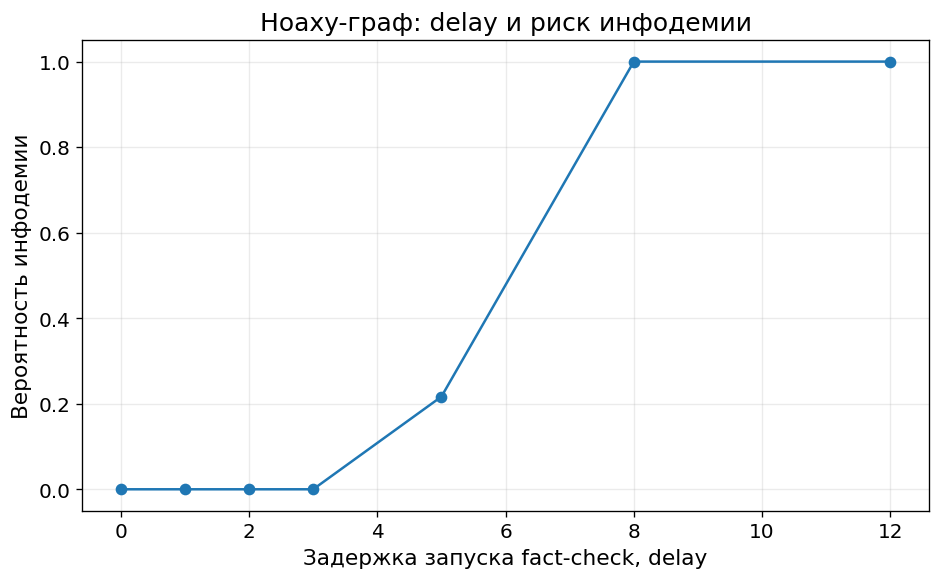

In [29]:
# ===== Cell 23. Hoaxy delay validation on the real graph =====


def scan_real_delay_effect(
    delay_values,
    strategy="influencer",
    n_runs=50,
    p=None,
    w=2.0,
    r=0.35,
    steps=30,
    outbreak_threshold=0.25,
    seed=42,
):
    if p is None:
        p = REAL_P_FOR_VALIDATION

    rng = np.random.default_rng(seed)
    rows = []

    # Общий набор fake-seeds для всех delay, чтобы сравнение было стабильнее.
    shared_fake_seeds_delay = [choose_real_fake_seed(rng=rng) for _ in range(n_runs)]

    for delay_val in tqdm(delay_values, desc="Hoaxy delay validation"):
        df = run_real_many(
            strategy=strategy,
            n_runs=n_runs,
            p=float(p),
            w=w,
            r=float(r),
            delay=int(delay_val),
            steps=steps,
            outbreak_threshold=outbreak_threshold,
            fake_seed_indices=shared_fake_seeds_delay,
            seed=int(rng.integers(1, 1_000_000_000)),
            show_progress=False,
        )

        rows.append({
            "delay": int(delay_val),
            "runs": n_runs,
            "outbreak_probability": df["outbreak"].mean(),
            "mean_final_fake_share": df["final_fake_share"].mean(),
            "sem_final_fake_share": df["final_fake_share"].sem(),
            "mean_ever_fake_share": df["ever_fake_share"].mean(),
            "sem_ever_fake_share": df["ever_fake_share"].sem(),
            "mean_peak_fake_share": df["peak_fake_share"].mean(),
            "sem_peak_fake_share": df["peak_fake_share"].sem(),
            "mean_final_checked_share": df["final_checked_share"].mean(),
            "mean_outside_origin_ever_share": df["outside_origin_ever_share"].mean(),
        })

    return pd.DataFrame(rows)


REAL_DELAY_VALUES = [0, 1, 2, 3, 5, 8, 12]
REAL_DELAY_RUNS = CONFIG["REAL_DELAY_RUNS"]

real_delay_df = scan_real_delay_effect(
    delay_values=REAL_DELAY_VALUES,
    strategy="influencer",
    n_runs=REAL_DELAY_RUNS,
    p=REAL_P_FOR_VALIDATION,
    w=REAL_W,
    r=REAL_R_FOR_VALIDATION,
    steps=REAL_STEPS,
    outbreak_threshold=REAL_OUTBREAK_THRESHOLD,
    seed=SEED + 11000,
)

display(real_delay_df)
real_delay_df.to_csv(TABLE_DIR / "hoaxy_real_graph_delay_effect.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(
    real_delay_df["delay"],
    real_delay_df["mean_final_fake_share"],
    yerr=1.96 * real_delay_df["sem_final_fake_share"],
    marker="o",
    capsize=3,
    label="Финальная доля F",
)
ax.errorbar(
    real_delay_df["delay"],
    real_delay_df["mean_peak_fake_share"],
    yerr=1.96 * real_delay_df["sem_peak_fake_share"],
    marker="o",
    capsize=3,
    label="Пиковая доля F",
)
ax.errorbar(
    real_delay_df["delay"],
    real_delay_df["mean_ever_fake_share"],
    yerr=1.96 * real_delay_df["sem_ever_fake_share"],
    marker="o",
    capsize=3,
    label="Хотя бы раз F",
)
ax.set_xlabel("Задержка запуска fact-check, delay")
ax.set_ylabel("Доля пользователей")
ax.set_title("Hoaxy-граф: влияние задержки fact-check на распространение F")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_delay_effect.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(real_delay_df["delay"], real_delay_df["outbreak_probability"], marker="o")
ax.set_xlabel("Задержка запуска fact-check, delay")
ax.set_ylabel("Вероятность инфодемии")
ax.set_title("Hoaxy-граф: delay и риск инфодемии")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_real_graph_delay_outbreak_probability.png", bbox_inches="tight")
plt.show()


## 24. Temporal split: предсказывает ли ранняя центральность будущий claim?

Это out-of-sample проверка.  
Центральности считаются только на ранней части данных, а затем проверяется, концентрируются ли будущие claim-события в заранее найденных центральных узлах.

Логика:

1. делим события по времени: первые 70% — train, последние 30% — test;
2. на train-графе считаем PageRank, degree, k-core и мостовые узлы;
3. в test-периоде считаем, сколько будущих claim-событий приходится на top-узлы;
4. сравниваем с random baseline.

Это усиливает валидацию, потому что показывает не только структурное совпадение, но и предсказательную роль топологии.


Temporal split cutoff: 2016-10-14 12:15:24
Train events: 489539
Test events: 186591


,score,top_fraction,top_k,top_mean_future_F,random_mean_future_F,mean_enrichment,top_sum_future_F,random_sum_future_F,sum_enrichment,randomization_p_value
0,train_pagerank,0.01,79,1679.949367,52.644810,31.911016,132716.0,4158.940,31.911016,0.004975
1,train_pagerank,0.05,399,404.015038,44.221667,9.136133,161202.0,17644.445,9.136133,0.004975
2,train_pagerank,0.10,799,226.150188,49.358598,4.581779,180694.0,39437.520,4.581779,0.004975
3,train_degree,0.01,79,1683.645570,43.491835,38.711762,133008.0,3435.855,38.711762,0.004975
4,train_degree,0.05,399,406.749373,43.921880,9.260746,162293.0,17524.830,9.260746,0.004975
5,train_degree,0.10,799,229.068836,46.349806,4.942175,183026.0,37033.495,4.942175,0.004975
6,train_core,0.01,79,268.037975,37.503671,7.146980,21175.0,2962.790,7.146980,0.004975
7,train_core,0.05,399,139.192982,44.943509,3.097065,55538.0,17932.460,3.097065,0.034826
8,train_core,0.10,799,227.545682,45.321064,5.020749,181809.0,36211.530,5.020749,0.004975


,train_bridge_endpoint,nodes,mean_future_F,total_future_F,mean_future_C,total_future_C,node_share,future_F_share,future_C_share
0,False,718,14.065460,10099,5.254875,3773,0.089761,0.02826,0.238405
1,True,7281,47.693586,347257,1.655404,12053,0.910239,0.97174,0.761595


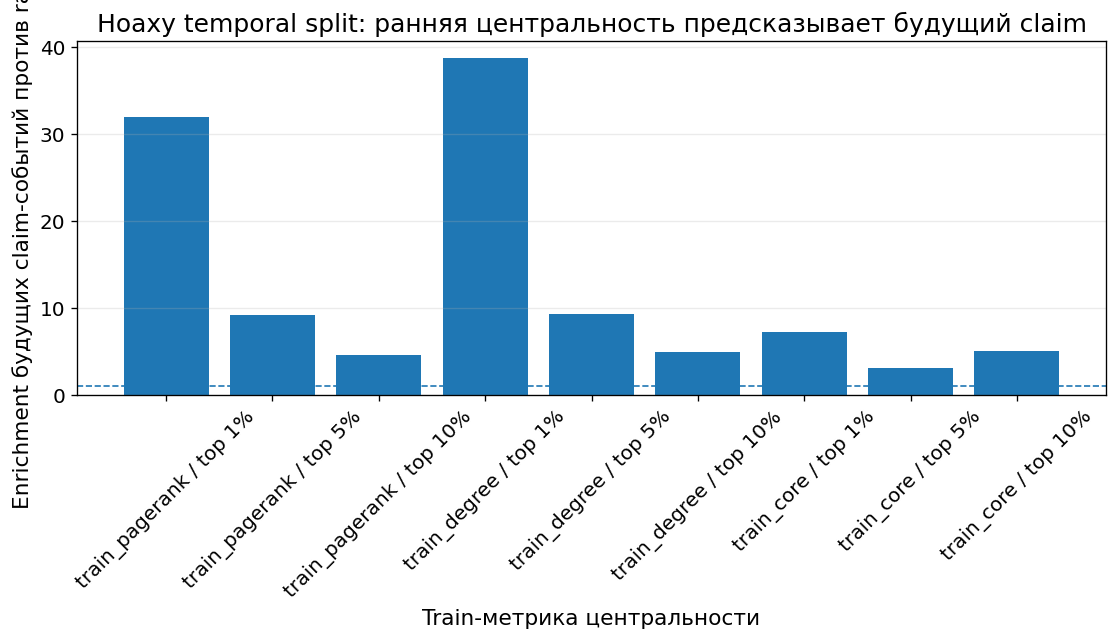

In [30]:
# ===== Cell 24. Temporal split: do central nodes predict future claim spread? =====

TEMPORAL_SPLIT_Q = 0.70
TEMPORAL_RANDOM_REPS = CONFIG["TEMPORAL_RANDOM_REPS"]
TEMPORAL_TOP_FRACTIONS = [0.01, 0.05, 0.10]

# Надежный cutoff для datetime.
sorted_times = events["timestamp"].sort_values().reset_index(drop=True)
cutoff_idx = int(TEMPORAL_SPLIT_Q * (len(sorted_times) - 1))
cutoff_time = sorted_times.iloc[cutoff_idx]

real_node_set = set(real_nodes.tolist())

train_events = events[
    (events["timestamp"] <= cutoff_time)
    & (events["source"].isin(real_node_set))
    & (events["target"].isin(real_node_set))
].copy()

test_events = events[
    (events["timestamp"] > cutoff_time)
    & (events["source"].isin(real_node_set))
    & (events["target"].isin(real_node_set))
].copy()

print("Temporal split cutoff:", cutoff_time)
print("Train events:", train_events.shape[0])
print("Test events:", test_events.shape[0])


def build_temporal_ugraph(ev, nodes):
    edge_counts = (
        ev.groupby(["source", "target"], as_index=False)
        .agg(n_events=("state", "size"))
    )

    H = nx.Graph()
    H.add_nodes_from(nodes)

    if len(edge_counts) == 0:
        return H

    x = np.log1p(edge_counts["n_events"].values.astype(float))
    q95 = np.quantile(x, 0.95) if len(x) else 1.0
    if q95 <= 0:
        q95 = 1.0

    for _, row in edge_counts.iterrows():
        w0 = float(np.clip(np.log1p(row["n_events"]) / q95, 0.05, 1.0))
        if H.has_edge(row["source"], row["target"]):
            H[row["source"]][row["target"]]["weight"] += w0
        else:
            H.add_edge(row["source"], row["target"], weight=w0)

    for u, v, d in H.edges(data=True):
        d["weight"] = float(np.clip(d.get("weight", 1.0), 0.05, 1.0))

    return H


H_train = build_temporal_ugraph(train_events, real_nodes.tolist())

try:
    train_communities = nx.community.louvain_communities(
        H_train,
        weight="weight",
        seed=SEED,
        resolution=1.0,
    )
    train_partition = {}
    for cid, nodes in enumerate(train_communities):
        for n in nodes:
            train_partition[n] = cid
except Exception as e:
    print("Train Louvain failed, fallback to python-louvain:", repr(e))
    import community as community_louvain
    train_partition = community_louvain.best_partition(
        H_train,
        weight="weight",
        random_state=SEED,
        resolution=1.0,
    )

nx.set_node_attributes(H_train, train_partition, "train_community")

train_degree = dict(H_train.degree(weight="weight"))
try:
    train_pagerank = nx.pagerank(H_train, weight="weight", max_iter=1000)
except nx.PowerIterationFailedConvergence:
    total_degree = sum(train_degree.values()) or 1.0
    train_pagerank = {n: train_degree[n] / total_degree for n in H_train.nodes()}

try:
    train_core = nx.core_number(H_train)
except nx.NetworkXError:
    train_core = {n: 0 for n in H_train.nodes()}

train_bridge_endpoint = {n: False for n in H_train.nodes()}
for u, v in H_train.edges():
    if train_partition.get(u) != train_partition.get(v):
        train_bridge_endpoint[u] = True
        train_bridge_endpoint[v] = True

future_F_source = test_events.loc[test_events["state"] == "F"].groupby("source").size()
future_F_target = test_events.loc[test_events["state"] == "F"].groupby("target").size()
future_C_source = test_events.loc[test_events["state"] == "C"].groupby("source").size()
future_C_target = test_events.loc[test_events["state"] == "C"].groupby("target").size()

pred_df = pd.DataFrame({"node": real_nodes})
pred_df["train_pagerank"] = pred_df["node"].map(train_pagerank).fillna(0.0)
pred_df["train_degree"] = pred_df["node"].map(train_degree).fillna(0.0)
pred_df["train_core"] = pred_df["node"].map(train_core).fillna(0.0)
pred_df["train_bridge_endpoint"] = pred_df["node"].map(train_bridge_endpoint).fillna(False).astype(bool)
pred_df["future_F_events"] = (
    pred_df["node"].map(future_F_source).fillna(0)
    + pred_df["node"].map(future_F_target).fillna(0)
).astype(int)
pred_df["future_C_events"] = (
    pred_df["node"].map(future_C_source).fillna(0)
    + pred_df["node"].map(future_C_target).fillna(0)
).astype(int)


def top_enrichment_table(
    df,
    score_cols=("train_pagerank", "train_degree", "train_core"),
    outcome_col="future_F_events",
    fractions=(0.01, 0.05, 0.10),
    random_reps=200,
    seed=42,
):
    rng = np.random.default_rng(seed)
    rows = []
    n = len(df)
    all_values = df[outcome_col].values.astype(float)

    for score_col in score_cols:
        ordered = df.sort_values(score_col, ascending=False)

        for frac in fractions:
            k = max(1, int(frac * n))
            top_values = ordered.head(k)[outcome_col].values.astype(float)
            top_mean = float(top_values.mean())
            top_sum = float(top_values.sum())

            random_means = []
            random_sums = []
            for _ in range(random_reps):
                idx = rng.choice(n, size=k, replace=False)
                vals = all_values[idx]
                random_means.append(float(vals.mean()))
                random_sums.append(float(vals.sum()))

            random_mean = float(np.mean(random_means))
            random_sum = float(np.mean(random_sums))
            p_value = (1 + np.sum(np.array(random_means) >= top_mean)) / (random_reps + 1)

            rows.append({
                "score": score_col,
                "top_fraction": frac,
                "top_k": k,
                "top_mean_future_F": top_mean,
                "random_mean_future_F": random_mean,
                "mean_enrichment": top_mean / max(random_mean, 1e-12),
                "top_sum_future_F": top_sum,
                "random_sum_future_F": random_sum,
                "sum_enrichment": top_sum / max(random_sum, 1e-12),
                "randomization_p_value": p_value,
            })

    return pd.DataFrame(rows)


temporal_enrichment = top_enrichment_table(
    pred_df,
    score_cols=("train_pagerank", "train_degree", "train_core"),
    outcome_col="future_F_events",
    fractions=TEMPORAL_TOP_FRACTIONS,
    random_reps=TEMPORAL_RANDOM_REPS,
    seed=SEED + 13000,
)

bridge_future_summary = (
    pred_df
    .groupby("train_bridge_endpoint")
    .agg(
        nodes=("node", "count"),
        mean_future_F=("future_F_events", "mean"),
        total_future_F=("future_F_events", "sum"),
        mean_future_C=("future_C_events", "mean"),
        total_future_C=("future_C_events", "sum"),
    )
    .reset_index()
)

bridge_future_summary["node_share"] = bridge_future_summary["nodes"] / bridge_future_summary["nodes"].sum()
bridge_future_summary["future_F_share"] = bridge_future_summary["total_future_F"] / max(1, bridge_future_summary["total_future_F"].sum())
bridge_future_summary["future_C_share"] = bridge_future_summary["total_future_C"] / max(1, bridge_future_summary["total_future_C"].sum())

display(temporal_enrichment)
display(bridge_future_summary)

temporal_enrichment.to_csv(TABLE_DIR / "hoaxy_temporal_centrality_enrichment.csv", index=False)
bridge_future_summary.to_csv(TABLE_DIR / "hoaxy_temporal_bridge_future_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
plot_temp = temporal_enrichment.copy()
plot_temp["label"] = plot_temp["score"] + " / top " + (100 * plot_temp["top_fraction"]).astype(int).astype(str) + "%"
ax.bar(plot_temp["label"], plot_temp["mean_enrichment"])
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_ylabel("Enrichment будущих claim-событий против random")
ax.set_xlabel("Train-метрика центральности")
ax.set_title("Hoaxy temporal split: ранняя центральность предсказывает будущий claim")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(VAL_OUT / "hoaxy_temporal_centrality_predicts_future_claim.png", bbox_inches="tight")
plt.show()


## 25. Индекс результатов для статьи

После полного запуска ноутбука основные таблицы будут лежать в папке `validation_tables`, а рисунки — в папке `validation_figs`.

Наиболее важные результаты для текста статьи:

1. `hoaxy_bridge_intra_claim_fact_summary.csv` — доля claim/fact-check на мостах и внутри сообществ;
2. `hoaxy_bridge_vs_intra_odds_ratio.csv` — статистический тест claim-доминирования на мостах;
3. `hoaxy_k_core_claim_fact_summary.csv` — распределение claim/fact-check по k-core;
4. `hoaxy_targeted_vs_random_removal.csv` — structural intervention;
5. `hoaxy_claim_cascade_features.csv` — каскадная валидация по tweet_id;
6. `hoaxy_empirical_pc_scan.csv` — эмпирический `p_c` на реальном графе;
7. `hoaxy_real_graph_strategy_summary.csv` — сравнение стратегий fact-check в исходной модели на реальной сети;
8. `hoaxy_real_graph_phase_pr_grid.csv` и `hoaxy_real_graph_pc_by_r.csv` — фазовая карта `p × r`;
9. `hoaxy_real_graph_delay_effect.csv` — эффект задержки;
10. `hoaxy_temporal_centrality_enrichment.csv` — out-of-sample проверка центральности.


In [31]:
# ===== Cell 25. Result index =====

print("Figures saved to:", FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob("*.png")):
    print("FIG ", p)

print("\nTables saved to:", TABLE_DIR.resolve())
for p in sorted(TABLE_DIR.glob("*.csv")):
    print("TABLE", p)


Figures saved to: /content/validation_figs
FIG  validation_figs/hoaxy_bridge_intra_claim_fact_share.png
FIG  validation_figs/hoaxy_cascade_bridge_cross_community.png
FIG  validation_figs/hoaxy_cascade_early_influencer_size.png
FIG  validation_figs/hoaxy_empirical_pc.png
FIG  validation_figs/hoaxy_k_core_claim_fact.png
FIG  validation_figs/hoaxy_observed_cumulative_dynamics.png
FIG  validation_figs/hoaxy_real_graph_delay_effect.png
FIG  validation_figs/hoaxy_real_graph_delay_outbreak_probability.png
FIG  validation_figs/hoaxy_real_graph_pc_by_r.png
FIG  validation_figs/hoaxy_real_graph_phase_pr_final.png
FIG  validation_figs/hoaxy_real_graph_phase_pr_outbreak.png
FIG  validation_figs/hoaxy_real_graph_strategy_ever_fake.png
FIG  validation_figs/hoaxy_real_graph_strategy_outbreak.png
FIG  validation_figs/hoaxy_targeted_vs_random_removal.png
FIG  validation_figs/hoaxy_temporal_centrality_predicts_future_claim.png

Tables saved to: /content/validation_tables
TABLE validation_tables/hoaxy_F_